# Quantitative evaluation of pupil filling factor variations.

This notebook establishes a rigorous framework for assessing how variations in the pupil filling factor influence the focal spot quality and aberrations in single-lens optical systems operating at 780 nm. The filling factor—defined as the ratio of the incident beam footprint to the clear aperture of the optical element—dictates the trade-off between power transmission efficiency and wavefront degradation induced by marginal rays traversing the outer regions of the lens surfaces. By systematically varying this parameter from 25% to 90% in 5% increments, we characterize the transition between diffraction-limited performance and aberration-dominated focal structures. The upper boundary corresponds to the conservative clear aperture limit guaranteed by component manufacturers such as Thorlabs, ensuring that the visual and numerical results directly map to physically realizable experimental conditions.

<div align="center">
  <img src="../images/notebooks/filling_factor_effect/optical_setup_schematic.png" alt="Optical setup schematic" width="30%"/>
</div>

The simulated setup consists of a monochromatic, perfectly collimated beam propagating parallel to the optical axis, directly impinging on the singlet lens without intermediate apertures or window optical surfaces. The analysis relies on ray-tracing data exported from a geometric optics simulator by Ansys, named Zemax OpticStudio to quantify a comprehensive set of metrics across different lens geometries. Beyond evaluating intensity profiles at the focal plane, this work examines the underlying phase anomalies across the exit pupil to provide a complete diagnostic of optical performance. Subsequent sections will systematically lay out the mathematical and physical foundations of these metrics—including the Huygens Point Spread Function (PSF), Strehl ratio, wavefront error, and Zernike polynomials—before detailing the automated data processing pipeline developed to extract, visualize, and compare performance trends across the tested optical components.

## What is the Huygens PSF and its cross-section?

The spatial distribution of optical power at the focal plane of an imaging system illuminated by a point source is fundamental to defining its spatial resolution and imaging fidelity. Physical optics models this distribution through the PSF, which accounts for wave diffraction governed by the wave equation as light traverses finite apertures and optical surfaces. Rather than treating light strictly as geometric rays, diffraction theory computes the interference of secondary wavelets originating from the optical pupil. The exact description of this wave propagation requires evaluating the **Huygens-Fresnel principle**, which asserts that *every unobstructed point on a propagating wavefront acts as a secondary spherical wave emitter whose mutual interference determines the complex amplitude at any subsequent observation surface*.

Numerical implementations of diffraction analysis rely on different mathematical simplifications of the optical path length between a pupil point and an image point:

$$r_{ij}=\sqrt{\left( x_i - x_j \right)^2 + \left( y_i - y_j \right)^2 + \left( z_i - z_j \right)^2}$$

Standard Fast Fourier Transform (FFT) methods propagate the entire pupil wavefront simultaneously by employing the Fraunhofer approximation, which assumes a far-field regime where the phase term depends linearly (first Taylor term) on pupil coordinates $\lbrace x_i, x_j, y_i, y_j, z_i, z_j \rbrace$. While computationally efficient, the Fraunhofer regime neglects higher-order distance variations across curved or heavily aberrated wavefronts. Intermediate regimes utilize the Fresnel approximation, which retains the parabolic quadratic term (second Taylor term) in the binomial expansion of $r_{ij}$ to model near-field propagation. To achieve maximum physical accuracy, Zemax OpticStudio also implements the Huygens PSF calculation, which avoids Taylor series truncations altogether by evaluating the exact Euclidean distance $r_{ij}$ between each pupil grid origin and image plane coordinate. Light rays are traced individually from a dense grid of point sources distributed across the exit pupil, and their complex wave amplitudes are integrated point by point at the detector plane to produce a two-dimensional intensity map.

The resulting two-dimensional Huygens PSF map provides a comprehensive visual representation of the focal intensity distribution, highlighting asymmetries, energy leakage, and halo structures caused by optical aberrations. To extract quantitative parameters from this surface, one-dimensional cross-sections are taken along orthogonal axes intersecting the center of maximum irradiance. These line profiles isolate the functional shape of the central diffraction peak and its surrounding Airy ring structures, enabling direct evaluation of metrics such as the full width at half maximum and side-lobe intensity ratios. Analyzing cross-sectional profiles across varying pupil filling factors reveals how marginal ray aberrations broaden the central lobe and redistribute energy into diffraction rings, degrading spatial concentration.

From these one-dimensional cross-sectional profiles, fundamental spatial dimensions of the focused beam can be extracted by determining the spatial threshold at which the normalized irradiance decays to specific fractional levels. A key metric evaluated throughout this work is the spot radius, defined at the $\frac{1}{e^2}$ threshold where the intensity drops to approximately 13.5% of its peak value. According to standard diffraction theory, expanding the illuminated pupil diameter increases the effective numerical aperture of the system, which dictates an inverse relationship between the entrance pupil footprint and the diffraction-limited focal spot size. Consequently, increasing the pupil filling factor is theoretical expectation to yield a narrower central lobe and a smaller $\frac{1}{e^2}$ spot radius, provided that geometric aberrations introduced by marginal rays do not dominate over diffraction limits.

<div style="display: flex; justify-content: center; align-items: center; gap: 20px;">
  <img src="../images/notebooks/filling_factor_effect/thorlabs_cross_section.png" alt="Thorlabs PSF cross section" style="max-width: 30%; height: auto;"/>
  <img src="../images/notebooks/filling_factor_effect/zemax_cross_section.png" alt="Zemax PSF cross section" style="max-width: 30%; height: auto;"/>
</div>

The side-by-side comparison displays the one-dimensional Huygens PSF cross-sectional profiles obtained from the manufacturer data sheet provided by Thorlabs and the corresponding simulation reproduced in Zemax OpticStudio for a selected aspheric lens (model 354060 from Thorlabs). Both profiles demonstrate exceptional agreement the geometry, validating the accuracy of the optical simulation setup and the underlying ray-tracing configurations prior to analyzing broader filling factor variations.

## What is the Strehl ratio?

The Strehl ratio, $S$, provides a single-value metric quantifying the degree to which an optical system approaches diffraction-limited performance in the presence of wavefront aberrations. It is defined as the ratio of the peak intensity of the actual aberrated PSF to the peak intensity of an ideal, aberration-free PSF generated by the same aperture geometry and wavelength:

$$S=\frac{I_{\text{max, abe}}^{\text{PSF}}}{I_{\text{max, no abe}}^{\text{PSF}}}$$

Bound strictly between 0 and 1, a Strehl ratio approaching unity signifies that the wavefront exiting the optical system retains near-perfect coherence and planar or spherical symmetry. According to Maréchal's criterion, an optical system is formally considered diffraction-limited when its Strehl ratio is equal to or greater than 0.8.

In this study, the Strehl ratio values are extracted directly from the Huygens PSF cross-section computation performed by Zemax OpticStudio. This method ensures that the metric accurately reflects the peak irradiance reduction derived from the exact physical optics beam propagation rather than simplified analytical models. However, it is important to note that Zemax documentation explicitly restricts the numerical reliability of this calculation to systems displaying a Strehl ratio above 0.1. Below this threshold, severe aberrations cause extreme spatial distortion and energy redistribution across the focal plane, rendering peak-based scalar approximations less reliable for describing the true optical quality.

## What is the wavefront error?

The wavefront error quantifies the phase deviation of an actual optical wave from an ideal, aberration-free reference wavefront as light propagates through an optical system. To construct this reference, paraxial rays are traced to locate the paraxial focal point, defining an ideal spherical reference wave centered at this focal point and passing through the center of the exit pupil. Real rays are subsequently traced across a defined sampling grid over the entrance pupil, and the Optical Path Difference (OPD) is computed by measuring the optical path length along each real ray relative to the reference sphere. Mapping these individual path differences across the aperture produces a two-dimensional OPD phase distribution that encapsulates all optical deformations induced by the system geometry.

To synthesize the continuous phase map into scalar metrics, two primary parameters are evaluated: the Peak-to-Valley (P-V) error and the Root-Mean-Square (RMS) wavefront error. The P-V error measures the maximum absolute difference between the highest peak and lowest valley of the phase map across the entire pupil, providing a strict worst-case metric that remains highly sensitive to localized surface defects or extreme marginal ray deviations. Conversely, the RMS wavefront error computes the standard deviation of the OPD map over the pupil area, offering a statistically robust measure of global wave deformation that correlates directly with overall spatial intensity degradation at the focal plane.

Zemax OpticStudio provides multiple pupil sampling schemes to compute the OPD map and derive these scalar metrics. Standard implementations utilize a rectangular grid array, which distributes sampling points uniformly within a bounding box matching the pupil dimensions. Alternatively, advanced calculations employ Gaussian quadrature techniques, which select non-uniform sampling coordinates across the pupil corresponding to Forbes nodes and assign specific Forbes integration weights $w_k$ to each ray coordinate. Integrating these Forbes weights with the measured wavefront errors $W_k$ allows the RMS wavefront error to be evaluated via the Rimmer algorithm:

$$\sigma \equiv W_{\text{RMS}} = \sqrt{\sum_{k=1}^{N} w_k \left( W_k - \bar{W} \right)^2}, \quad \text{where} \quad \bar{W} = \sum_{k=1}^{N} w_k W_k$$

By leveraging Gaussian quadrature and Rimmer's formulation, the RMS wavefront error is integrated with exceptional numerical accuracy using significantly fewer traced rays than required by dense, uniform rectangular grids.

## What are the Zernike coefficients?

The mathematical description of optical phase deformations across a circular pupil can be formulated using either classical power series expansions or orthogonal polynomial bases. In classical aberration theory, Born and Wolf express the wave aberration function $W(\rho, \theta)$ as a double power series in normalized radial distance $\rho$ and azimuthal angle $\theta$, where primary Seidel aberrations correspond to lower-order coefficients $W_{klm}$:

$$W(\rho, \theta) = \sum_{k} \sum_{l} \sum_{m} W_{klm} \, H^k \rho^l \cos^m\theta$$

where $H$ represents the normalized field height. While this classical power series directly links geometrical ray parameters to third-order Seidel terms, its individual basis functions are not orthogonal over the circular pupil. Consequently, altering one classical term modifies the mean phase value and degrades other metrics, making it difficult to isolate individual physical contributions independently.

To overcome the lack of orthogonality, Standard Zernike polynomials $Z_i(\rho, \theta)$ provide a complete, orthonormal basis defined specifically over a unit circular aperture. Similar to how a Fourier transform decomposes a time-domain signal into an orthogonal spectrum of harmonic frequencies, any arbitrary phase deformation $W(\rho, \theta)$ can be uniquely expanded into a linear combination of these orthogonal modes weighted by scalar Zernike coefficients $c_i$:

$$W(\rho, \theta) = \sum_{i=0}^{\infty} c_i Z_i(\rho, \theta)$$

Because the underlying spatial functions $Z_i(\rho, \theta)$ are analytical and fixed by definition over the circular pupil, the primary diagnostic objective in wave optics is to evaluate and track the scalar Zernike coefficients $c_i$. Furthermore, owing to the strict orthogonality of the basis, the variance of the wavefront error $\sigma^2$ simplifies directly to the sum of the squared non-piston expansion coefficients:

$$\sigma^2 = \sum_{i=1}^{\infty} c_i^2$$

Each Zernike coefficient $c_i$ isolates the exact physical contribution of a distinct mode of optical deformation, providing a balanced representation that maps directly to classical Born-Wolf and Seidel primary aberrations.

<div align="center">

| Aberration | Born-Wolf / Seidel Term | Standard Zernike Term | Physical Impact |
|:---:|:---:|:---:|:---:|
| **Defocus** | $W_{020} \, \rho^2$ | $Z_4 \propto 2\rho^2 - 1$ | Longitudinal displacement of the focus along the optical axis |
| **Astigmatism** | $W_{222} \, \rho^2 \cos^2\theta$ | $Z_5, Z_6 \propto \rho^2 \cos(2\theta)$ | Asymmetrical focal power along orthogonal transverse axes |
| **Coma** | $W_{311} \, \rho^3 \cos\theta$ | $Z_7, Z_8 \propto (3\rho^3 - 2\rho) \cos\theta$ | Asymmetric, comet-like tailing off-axis due to non-uniform magnification |
| **Spherical Aberration** | $W_{040} \, \rho^4$ | $Z_{11} \propto 6\rho^4 - 6\rho^2 + 1$ | Marginal rays focus closer or further than paraxial rays along the axis |

</div>

Analyzing how these specific coefficients $c_i$ scale as a function of the pupil filling factor reveals the underlying geometrical phase modes responsible for optical quality degradation across different lens profiles.

## Link between Strehl ratio and RMS wavefront error.

The quantitative bridge linking scalar focal quality to exit pupil phase variance relies on analytical approximations connecting the Strehl ratio $S$ with the Root-Mean-Square wavefront error $\sigma$ (expressed in units of wavelength $\lambda$). Classical diffraction theory by Maréchal, as well as Born and Wolf, demonstrates that evaluating the Strehl definition for well-behaved, low-magnitude phase fluctuations yields a Taylor series expansion of the form 

$$S =\frac{I_{\text{max, abe}}^{\text{PSF}}}{I_{\text{max, no abe}}^{\text{PSF}}} \simeq 1 - (2\pi\sigma)^2 + \dots$$

where the factor of $2\pi$ converts the RMS OPD from wavelengths to phase variance in radians, $\sigma_\phi^2 = (2\pi\sigma)^2$. This truncated quadratic expansion can be interpreted as the leading-order Taylor series representation of several distinct function families, including the exponential envelope $e^{-\sigma_\phi^2}$, the even powers of the sinc squared profile $\left(\frac{\sin(\sigma_\phi)}{\sigma_\phi}\right)^{2n}$, the hyperbolic secant $\text{sech}(\sigma_\phi)$, and Airy-like functional shapes. Extensive numerical modeling across diverse incident beam profiles—including uniform circular apertures, flat-top beams, and high-order Gaussian or super-Gaussian distributions—has confirmed that the exponential approximation maintains robust empirical fidelity over broad parameter spaces.

A more fundamental statistical foundation for this empirical link was established by Ross in 2009, who generalized the relationship between pupil phase distributions and far-field intensity. Ross showed that the Strehl ratio can be expressed as 

$$S = \sigma^2 \lvert\mathcal{F}[\text{PDF}(\hat{\xi})]\rvert^2$$

where $\mathcal{F}$ represents the Fourier transform and $\text{PDF}(\hat{\xi})$ is the Probability Density Function (PDF) of the phase aberration variables $\hat{\xi}$ evaluated across the aperture. A critical insight of this statistical formulation is that when the underlying aberration PDF follows a Gaussian distribution, the Fourier transform yields an exact exponential equality matching the classic Maréchal form $S = e^{-\sigma_\phi^2}$. Furthermore, by virtue of the Central Limit Theorem, as an optical system accumulates multiple independent aberration modes ($\hat{\xi} = \sum \hat{\xi}_i$), the net phase PDF naturally converges toward a Gaussian distribution, explaining why the exponential model remains highly effective even in systems with complex, non-Gaussian individual surface errors.

Ross further demonstrated that in the regime of high optical quality where the Strehl ratio exceeds 0.8, all these candidate mathematical approximations (quadratic, exponential, sinc, or hyperbolic) converge to virtually identical numerical values. This high-Strehl domain provides a rigorously safe analytical zone where the choice of functional model becomes negligible. Crucially, evaluating Maréchal's diffraction-limited criterion ($S \ge 0.8$) within the quadratic expansion $S \simeq 1 - (2\pi\sigma)^2$ directly yields the classic tolerance threshold $\sigma \le \frac{1}{14}$ (or $\frac{\lambda}{14}$), establishing a mathematically consistent boundary across spatial phase metrics, statistical aberration distributions, and focal plane power concentration.

## Zemax simulations procedure.

The simulation workflow was designed to systematically evaluate a selected set of commercial single lenses across a broad range of operational apertures. For each lens geometry, the initial focal distance was set according to the manufacturer specifications provided by Thorlabs, incorporating the wavelength-specific focal shift correction at 780 nm whenever provided (such as in achromatic doublets). For each lens model, the entrance pupil diameter was incrementally expanded from 25% to 90% of the maximum clear aperture in 5% steps. At each filling factor step, an automated Quick Focus optimization routine was executed to reposition the image plane at the exact axial location that minimized the RMS wavefront error. This focal position exhibited high sensitivity to the pupil filling factor, shifting from a few micrometers to several millimeters depending on the lens curvature, prescription, and severity of marginal ray spherical aberration.

Prior to executing the final sweep, extensive preliminary test simulations were conducted across all candidate lenses to establish fixed, high-precision calculation parameters that guaranteed numerical convergence. For the Zernike polynomial analysis, the pupil sampling grid was fixed at $512 \times 512$ rays to ensure accurate coefficient fitting up to the 40th Standard Zernike term, balancing pupil resolution against computational overhead. For the Huygens PSF cross-section calculations, a pupil sampling grid of $512 \times 512$ rays was coupled with an image sampling detector array of $256 \times 256$ points. The image space sampling interval (Image Delta) was kept at its default value to allow Zemax to dynamically scale the grid bounds based on diffraction geometry. Additionally, the resulting PSF profiles were normalized to unity intensity; while Zemax natively normalizes profiles against an ideal aberration-free system—where the central peak directly reflects the Strehl ratio—this default scaling renders severe, low-Strehl aberration structures visually unreadable due to extreme peak attenuation.

Following parameter stabilization, the complete parametric sweep was executed systematically. For every filling factor increment and lens model, a standardized data packet was exported, consisting of an optical layout schematic image, a text file containing the fitted Standard Zernike coefficients up to $Z_{40}$, and both image graphics and raw text data files for the Huygens PSF cross-section. Processing each individual filling factor configuration required approximately 8 to 10 minutes of computational and manual setup time per step, approximately 2 hour per lens. Accounting for preliminary parameter validation, alignment troubleshooting, and systematic data verification across the full lens catalog, this parametric characterization represents an intensive experimental procedure comprising dozens of individual optical state evaluations.

## Data analysis pipeline.

To process the heterogeneous raw output text files generated by Zemax OpticStudio across all simulated filling factors, an automated Python data ingestion pipeline was implemented. The primary function `compile_lens_data` systematically traverses the directory structure associated with each simulated lens model, locating the subfolders representing each pupil percentage step from 25% to 90%. For every state, the script invokes dedicated parser functions designed to extract scalar and array metrics from UTF-16 encoded text exports. The Huygens PSF cross-section data is parsed via `parse_huygens_psf` to extract the calculated Strehl ratio and compute the radial beam spot size. The spot size determination identifies the maximum irradiance peak, normalizes the radial intensity distribution, and performs linear interpolation between adjacent sampling coordinates to locate the exact spatial radius corresponding to the selected threshold—configured by default to the $\frac{1}{e^2}$ relative intensity level.

Phase error metrics and Zernike modal contributions are simultaneously ingested using `parse_zernike_coefficients`. This function extracts global scalar parameters—specifically the Peak-to-Valley error and the RMS wavefront error evaluated both directly from ray tracing integration and from fitted polynomial coefficients—while extracting specified Standard Zernike coefficients ($Z_4, Z_{11}, Z_{22}, Z_{37}$). Additionally, the ingestion pipeline includes auxiliary parsers such as `parse_encircled_energy` to evaluate real and diffraction-limited encircled energy radii. While additional metrics like encircled energy were parsed into the underlying data structure, they were intentionally excluded from the final comparative visualizations to avoid overwhelming the reader with redundant diagnostics and to maintain focus on the core phase and intensity trends.

All extracted metrics corresponding to a given lens model are assembled into a structured `pandas.DataFrame`, indexed and sorted chronologically by the pupil filling factor. Compiling the optical state data into standardized DataFrames enables direct programmatic execution of downstream visualization routines, curve fitting, and comparative trend analysis across different lens geometries, forming the data foundation for the results discussed in subsequent sections.

In [43]:
import re
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import pandas as pd
from scipy.interpolate import make_interp_spline

def parse_huygens_psf(file_path, threshold_mode="1/e2"):
    """Parses Huygens PSF data to extract Strehl ratio and calculate beam spot size.

    Args:
        file_path (str or Path): Path to the huygens_cross_section.txt file.
        threshold_mode (str or float): Evaluation criterion for spot size.
            Accepts '1/e', '1/e2', a percentage string (e.g. '50%'),
            a fraction (e.g. 0.5), or a percentage value (e.g. 50.0).

    Returns:
        dict: Contains 'strehl' (float) and 'spot_radius_um' (float).
    """
    # Convert input path to a Path object for easier file handling
    file_path = Path(file_path)
    # Read the text content using utf-16 encoding, typical for Zemax text exports
    content = file_path.read_text(encoding="utf-16")

    # Search for the Strehl ratio value in the text file using regex
    strehl_match = re.search(r"Strehl\s+ratio:\s*([\d,]+)", content)
    if not strehl_match:
        raise ValueError(f"Strehl ratio not found in {file_path.name}")

    # Convert the matched string value to a float, replacing commas with dots
    strehl_val = float(strehl_match.group(1).replace(",", "."))

    # Determine the intensity threshold ratio based on the chosen mode
    if isinstance(threshold_mode, str):
        mode_clean = threshold_mode.strip().lower()
        if mode_clean == "1/e":
            threshold_ratio = 1.0 / np.e
        elif mode_clean == "1/e2":
            threshold_ratio = 1.0 / (np.e**2)
        elif mode_clean.endswith("%"):
            threshold_ratio = float(mode_clean[:-1].replace(",", ".")) / 100.0
        else:
            try:
                val = float(mode_clean.replace(",", "."))
                threshold_ratio = val / 100.0 if val > 1.0 else val
            except ValueError:
                raise ValueError(
                    f"Invalid threshold_mode string: '{threshold_mode}'."
                )
    elif isinstance(threshold_mode, (int, float)):
        threshold_ratio = (
            threshold_mode / 100.0 if threshold_mode > 1.0 else float(threshold_mode)
        )
    else:
        raise TypeError("threshold_mode must be a string, float, or integer.")

    # Parse numerical PSF data points from the file
    data_lines = []
    is_data_zone = False

    for line in content.splitlines():
        line = line.strip()
        # Locate the header indicating the start of the data table
        if "Data" in line and "Position" in line and "Value" in line:
            is_data_zone = True
            continue
        # Extract spatial position and intensity value pairs
        if is_data_zone and line:
            parts = line.split()
            if len(parts) >= 3 and parts[0].isdigit():
                position = float(parts[1].replace(",", "."))
                value = float(parts[2].replace(",", "."))
                data_lines.append((position, value))

    if not data_lines:
        raise ValueError(f"No valid PSF data rows found in {file_path.name}")

    # Separate positions and values into numpy arrays
    positions, values = zip(*data_lines)
    positions = np.array(positions)
    values = np.array(values)

    # Identify the maximum intensity peak
    max_idx = np.argmax(values)
    max_val = values[max_idx]

    if max_val <= 0:
        raise ValueError(f"Invalid peak intensity in {file_path.name}")

    # Normalize intensity profile relative to the peak value
    normalized_values = values / max_val

    # Consider only the radial profile from the center outwards
    positive_positions = positions[max_idx:] - positions[max_idx]
    positive_values = normalized_values[max_idx:]

    # Locate where the normalized intensity drops below the defined threshold
    below_threshold_indices = np.where(positive_values <= threshold_ratio)[0]
    if len(below_threshold_indices) == 0:
        spot_radius = positive_positions[-1]
    else:
        crossing_idx = below_threshold_indices[0]
        if crossing_idx == 0:
            spot_radius = positive_positions[0]
        else:
            # Perform linear interpolation to calculate precise threshold position
            pos_low = positive_positions[crossing_idx - 1]
            pos_high = positive_positions[crossing_idx]
            val_high = positive_values[crossing_idx - 1]
            val_low = positive_values[crossing_idx]

            spot_radius = pos_low + (threshold_ratio - val_high) * (
                pos_high - pos_low
            ) / (val_low - val_high)

    return {"strehl": strehl_val, "spot_radius_um": abs(spot_radius)}

def _parse_zone_data(zone_text):
    # Helper function to extract radial distance and fraction arrays from a text block
    r_list, f_list = [], []
    active = False
    for line in zone_text.splitlines():
        line = line.strip()
        # Find start of data section
        if "Radial distance" in line and "Fraction" in line:
            active = True
            continue
        # Parse data lines until encountering a non-data header
        if active and line:
            if line.startswith(("Diff.", "Field", "Coordinates")):
                break
            parts = line.split()
            if len(parts) >= 2:
                try:
                    r_list.append(float(parts[0].replace(",", ".")))
                    f_list.append(float(parts[1].replace(",", ".")))
                except ValueError:
                    continue
    return np.array(r_list), np.array(f_list)

def parse_encircled_energy(file_path, energy_fraction=0.80):
    # Read encircled energy file export from Zemax
    file_path = Path(file_path)
    content = file_path.read_text(encoding="utf-16")

    # Separate file contents into diffraction-limited and real field zones
    field_zones = content.split("Field:")
    if len(field_zones) < 2:
        raise ValueError(f"Real field data block not found in {file_path.name}.")

    # Parse values for diffraction-limited and real optical systems
    r_diff, f_diff = _parse_zone_data(field_zones[0])
    r_real, f_real = _parse_zone_data(field_zones[1])

    if r_diff.size == 0 or r_real.size == 0:
        raise ValueError(f"Missing valid data block in {file_path.name}")

    # Interpolate radial distance corresponding to target energy fraction
    def get_interpolated_radius(f_arr, r_arr, target_fraction):
        if len(f_arr) == 0 or target_fraction > f_arr[-1]:
            return np.nan
        return float(np.interp(target_fraction, f_arr, r_arr))

    diff_radius = get_interpolated_radius(f_diff, r_diff, energy_fraction)
    real_radius = get_interpolated_radius(f_real, r_real, energy_fraction)

    return {"real_radius_um": real_radius, "diff_radius_um": diff_radius}

def parse_zernike_coefficients(file_path, zernike_terms=(4, 11, 22, 37)):
    # Parse Zernike coefficient text files for wavefront error analysis
    file_path = Path(file_path)
    content = file_path.read_text(encoding="utf-16")

    results = {
        "rms_rays": None,
        "rms_fitted": None,
        "peak_to_valley": None,
        "zernike_coefficients": {},
    }

    target_z_keys = {f"Z {z}": z for z in zernike_terms}

    in_rays_block = False
    in_fitted_block = False

    for line in content.splitlines():
        line_str = line.strip()

        # Extract Peak to Valley metric directly from header line
        if "Peak to Valley (to centroid)" in line_str:
            results["peak_to_valley"] = float(
                line_str.split(":")[1].split()[0].replace(",", ".")
            )

        # Track block context for ray integration versus fitted coefficients
        if "From integration of the rays:" in line_str:
            in_rays_block = True
            in_fitted_block = False
            continue
        elif "From integration of the fitted coefficients:" in line_str:
            in_rays_block = False
            in_fitted_block = True
            continue
        elif "RMS fit error" in line_str:
            in_rays_block = False
            in_fitted_block = False

        # Extract RMS wavefront errors
        if in_rays_block and "RMS (to chief)" in line_str:
            results["rms_rays"] = float(
                line_str.split(":")[1].split()[0].replace(",", ".")
            )

        if in_fitted_block and "RMS (to chief)" in line_str:
            results["rms_fitted"] = float(
                line_str.split(":")[1].split()[0].replace(",", ".")
            )

        # Extract requested specific Zernike terms
        if line_str.startswith("Z "):
            parts = line_str.split(":")
            z_header = parts[0].strip().split()
            if len(z_header) >= 2:
                z_name = f"Z {z_header[1]}"
                if z_name in target_z_keys:
                    val_str = z_header[2].replace(",", ".")
                    results["zernike_coefficients"][
                        f"Z_{target_z_keys[z_name]}"
                    ] = float(val_str)

    return results


def compile_lens_data(root_dir, threshold_mode="1/e2", energy_fraction=0.80, zernike_terms=(4, 11, 22, 37)):
    """Walks through the filling factor folders, parses Zemax output text files,

    and compiles all relevant optical metrics into a sorted pandas DataFrame.
    """
    root_path = Path(root_dir)
    records = []

    # Traverse directory structure searching for percentage folders
    for folder in root_path.iterdir():
        if folder.is_dir():
            match = re.search(r"(\d+)%", folder.name)
            if not match:
                continue

            filling_factor = float(match.group(1))

            # Locate expected Zemax result files in each directory
            psf_file = folder / "huygens_cross_section.txt"
            zernike_file = folder / "zernike_coeffs.txt"
            energy_file = folder / "encircled_energy.txt"

            if (
                not psf_file.exists()
                or not zernike_file.exists()
                or not energy_file.exists()
            ):
                continue

            # Parse metrics across all files for the current filling factor
            psf_data = parse_huygens_psf(psf_file, threshold_mode=threshold_mode)
            zernike_data = parse_zernike_coefficients(
                zernike_file, zernike_terms=zernike_terms
            )
            energy_data = parse_encircled_energy(
                energy_file, energy_fraction=energy_fraction
            )

            # Assemble parsed metrics into a structured dictionary record
            record = {
                "filling_factor": filling_factor,
                "strehl": psf_data["strehl"],
                "spot_radius_um": psf_data["spot_radius_um"],
                "energy_radius_real_um": energy_data["real_radius_um"],
                "energy_radius_diff_um": energy_data["diff_radius_um"],
                "rms_rays": zernike_data["rms_rays"],
                "rms_fitted": zernike_data["rms_fitted"],
                "peak_to_valley": zernike_data["peak_to_valley"],
            }

            for z_key, z_val in zernike_data["zernike_coefficients"].items():
                record[z_key] = z_val

            records.append(record)

    if not records:
        raise ValueError(
            f"No valid data records could be compiled from {root_dir}"
        )

    # Convert records into a single dataframe sorted by filling factor
    df = pd.DataFrame(records)
    df = df.sort_values(by="filling_factor").reset_index(drop=True)

    return df

## Simulated lenses and comparison groups.

To systematically analyze the impact of spherical aberration and geometric parameters on beam focusing quality under truncated Gaussian illumination, a total of twelve commercial optical configurations were modeled alongside an ideal paraxial baseline of $f = 100\text{ mm}$. The selected catalog includes precision diffraction-limited aspheric lenses, 2-inch and 1-inch B-coated achromatic doublets, and 2-inch B-coated N-BK7 plano-convex lenses. By varying the lens diameter, focal lengths $\left(f = 50, 100, 150, \text{and } 200\text{ mm}\right)$, and lens orientation, this dataset isolates specific optical phenomena and geometrical dependencies as a function of the pupil filling factor.

To extract clear physical insights from the compiled simulations without confounding variables, the datasets were organized into seven distinct comparison groups. Group 1 compares direct focal length $f = 100\text{ mm}$ geometries across different lens design families to evaluate how intrinsic aberration correction alters spot quality. Groups 2, 3, and 4 isolate the sensitivity of orientation by comparing forward-facing (direct) and reversed (inverted) configurations for 2-inch achromatic doublets, aspheric lenses, and plano-convex lenses, respectively. Groups 5 and 6 isolate the effect of the f-number $\left(f/\# = \frac{f}{\varnothing}\right)$ by varying the focal length while keeping the outer diameter fixed at 2 inches for achromats and plano-convex designs. Finally, Group 7 evaluates aperture scaling effects by contrasting 1-inch and 2-inch achromatic doublets across matching and scaled focal lengths.

<div align="center">

| Group | Functional name | Lens type | Focal length $\left(f\right)$ | Diameter $\left(\varnothing\right)$ |
|:---:|:---:|:---:|:---:|:---:|
| **Group 1** | **Direct lenses comparison** | Paraxial<br>Aspheric<br>Achromat<br>Plano-convex | $100\text{ mm}$<br>$100\text{ mm}$<br>$100\text{ mm}$<br>$100\text{ mm}$ | —<br>$2\text{"} \ (50.8\text{ mm})$<br>$2\text{"} \ (50.8\text{ mm})$<br>$2\text{"} \ (50.8\text{ mm})$ |
| **Group 2** | **Inversion effect (achromat)** | Paraxial<br>Achromat<br>Inverted achromat | $100\text{ mm}$<br>$100\text{ mm}$<br>$100\text{ mm}$ | —<br>$2\text{"} \ (50.8\text{ mm})$<br>$2\text{"} \ (50.8\text{ mm})$ |
| **Group 3** | **Inversion effect (aspheric)** | Paraxial<br>Aspheric<br>Inverted aspheric | $100\text{ mm}$<br>$100\text{ mm}$<br>$100\text{ mm}$ | —<br>$2\text{"} \ (50.8\text{ mm})$<br>$2\text{"} \ (50.8\text{ mm})$ |
| **Group 4** | **Inversion effect (plano-convex)** | Paraxial<br>Plano-convex<br>Inverted plano-convex | $100\text{ mm}$<br>$100\text{ mm}$<br>$100\text{ mm}$ | —<br>$2\text{"} \ (50.8\text{ mm})$<br>$2\text{"} \ (50.8\text{ mm})$ |
| **Group 5** | **Focal length effect (achromat)** | Paraxial<br>Achromat<br>Achromat<br>Achromat| $100\text{ mm}$<br>$100\text{ mm}$<br>$150\text{ mm}$<br>$200\text{ mm}$ | —<br>$2\text{"} \ (50.8\text{ mm})$<br>$2\text{"} \ (50.8\text{ mm})$<br>$2\text{"} \ (50.8\text{ mm})$ |
| **Group 6** | **Focal length effect (plano-convex)** | Paraxial<br>Plano-convex<br>Plano-convex<br>Plano-convex | $100\text{ mm}$<br>$100\text{ mm}$<br>$150\text{ mm}$<br>$200\text{ mm}$ | —<br>$2\text{"} \ (50.8\text{ mm})$<br>$2\text{"} \ (50.8\text{ mm})$<br>$2\text{"} \ (50.8\text{ mm})$ |
| **Group 7** | **Diameter effect** | Paraxial<br>Achromat<br>Achromat<br>Achromat<br>Achromat | $100\text{ mm}$<br>$100\text{ mm}$<br>$50\text{ mm}$<br>$200\text{ mm}$<br>$100\text{ mm}$ | —<br>$2\text{"} \ (50.8\text{ mm})$<br>$1\text{"} \ (25.4\text{ mm})$<br>$2\text{"} \ (50.8\text{ mm})$<br>$1\text{"} \ (25.4\text{ mm})$ |

</div>

In [44]:
# Set base path relative to the notebook or script location
# .parent goes up from 'src' to the root 'TFM' folder
base_dir = (Path(__file__).resolve().parent.parent if '__file__' in globals() else Path.cwd().parent)
simulations_path = base_dir / "results" / "zemax_simulations" / "filling_factor_effect"

# Dictionary storing all simulation relative paths
paths = {
    # Direct f100 lenses
    "paraxial": simulations_path / "ideal_paraxial_lens" / "f100" / "results",
    "aspheric": simulations_path / "aspheric_difflim_780_Bcoated" / "f100" / "results",
    "achromat_2inch_f100": simulations_path / "mounted_achromatic_doublets_Bcoated" / "2inch" / "f100" / "results",
    "planoconvex_f100": simulations_path / "mounted_NBK7_Bcoated" / "2inch" / "f100" / "results",
    
    # Inverted f100 lenses
    "inverted_aspheric": simulations_path / "inverted_lenses_f100" / "aspheric_difflim_780_Bcoated" / "results",
    "inverted_achromat_2inch_f100": simulations_path / "inverted_lenses_f100" / "mounted_achromatic_doublets_Bcoated_2inch" / "results",
    "inverted_planoconvex_f100": simulations_path / "inverted_lenses_f100" / "mounted_NBK7_Bcoated_2inch" / "results",
    
    # 2-inch achromat and planoconvex lenses
    "achromat_2inch_f150": simulations_path / "mounted_achromatic_doublets_Bcoated" / "2inch" / "f150" / "results",
    "achromat_2inch_f200": simulations_path / "mounted_achromatic_doublets_Bcoated" / "2inch" / "f200" / "results",
    "planoconvex_f150": simulations_path / "mounted_NBK7_Bcoated" / "2inch" / "f150" / "results",
    "planoconvex_f200": simulations_path / "mounted_NBK7_Bcoated" / "2inch" / "f200" / "results",
    
    # 1-inch achromat lenses
    "achromat_1inch_f50": simulations_path / "mounted_achromatic_doublets_Bcoated" / "1inch" / "f50" / "results",
    "achromat_1inch_f100": simulations_path / "mounted_achromatic_doublets_Bcoated" / "1inch" / "f100" / "results",
}

# Compile DataFrames for each optical setup into a dictionary
dfs = {key: compile_lens_data(path) for key, path in paths.items()}

# Defined plot groups with corresponding DataFrames and clean legend labels

# 1. Comparison of direct f=100 mm lenses
group1_dfs = [
    dfs["paraxial"],
    dfs["aspheric"],
    dfs["achromat_2inch_f100"],
    dfs["planoconvex_f100"],
]
group1_labels = [
    "Paraxial (f=100 mm)",
    "Aspheric (f=100 mm)",
    "Achromat 2\" (f=100 mm)",
    "Plano-convex 2\" (f=100 mm)",
]

# 2. Direct vs Inverted Achromat 2" f=100 mm
group2_dfs = [
    dfs["paraxial"],
    dfs["achromat_2inch_f100"],
    dfs["inverted_achromat_2inch_f100"],
]
group2_labels = [
    "Paraxial (f=100 mm)",
    "Achromat 2\" (f=100 mm)",
    "Inverted Achromat 2\" (f=100 mm)",
]

# 3. Direct vs Inverted Aspheric f=100 mm
group3_dfs = [
    dfs["paraxial"],
    dfs["aspheric"],
    dfs["inverted_aspheric"],
]
group3_labels = [
    "Paraxial (f=100 mm)",
    "Aspheric (f=100 mm)",
    "Inverted Aspheric (f=100 mm)",
]

# 4. Direct vs Inverted Plano-convex 2" f=100 mm
group4_dfs = [
    dfs["paraxial"],
    dfs["planoconvex_f100"],
    dfs["inverted_planoconvex_f100"],
]
group4_labels = [
    "Paraxial (f=100 mm)",
    "Plano-convex 2\" (f=100 mm)",
    "Inverted Plano-convex 2\" (f=100 mm)",
]

# 5. Focal length variation for 2" Achromat doublets
group5_dfs = [
    dfs["paraxial"],
    dfs["achromat_2inch_f100"],
    dfs["achromat_2inch_f150"],
    dfs["achromat_2inch_f200"],
]
group5_labels = [
    "Paraxial (f=100 mm)",
    "Achromat 2\" (f=100 mm)",
    "Achromat 2\" (f=150 mm)",
    "Achromat 2\" (f=200 mm)",
]

# 6. Focal length variation for 2" Plano-convex lenses
group6_dfs = [
    dfs["paraxial"],
    dfs["planoconvex_f100"],
    dfs["planoconvex_f150"],
    dfs["planoconvex_f200"],
]
group6_labels = [
    "Paraxial (f=100 mm)",
    "Plano-convex 2\" (f=100 mm)",
    "Plano-convex 2\" (f=150 mm)",
    "Plano-convex 2\" (f=200 mm)",
]

# 7. Comparison of 1" and 2" Achromat doublets
group7_dfs = [
    dfs["paraxial"],
    dfs["achromat_2inch_f100"],
    dfs["achromat_1inch_f50"],
    dfs["achromat_2inch_f200"],
    dfs["achromat_1inch_f100"],
]
group7_labels = [
    "Paraxial (f=100 mm)",
    "Achromat 2\" (f=100 mm)",
    "Achromat 1\" (f=50 mm)",
    "Achromat 2\" (f=200 mm)",
    "Achromat 1\" (f=100 mm)",
]

## General performance plot.

To evaluate beam quality degradation under increasing pupil filling factors, a dedicated visualization routine `plot_general_performance` was implemented. This function generates a $2\times2$ grid displaying the four primary optical parameters as a function of the truncation filling factor: the Strehl ratio (top-left), the Huygens Point Spread Function (PSF) spot radius in micrometers (top-right), the root-mean-square (RMS) wavefront error in waves (bottom-left), and the peak-to-valley (P-V) wavefront error in waves (bottom-right). To facilitate accurate trend visualization, raw simulation points are interpolated using cubic splines ($k = 3$), while logarithmic scaling is applied to the wavefront error axes to capture multi-order variations cleanly across different aberration regimes.

For automated quality assessment, the visualization incorporates Maréchal’s diffraction limit criterion as dash-dotted reference baselines. These thresholds define the operational boundary above which the focused beam remains diffraction-limited, allowing immediate identification of the critical filling factor where optical aberrations begin to degrade focal spot intensity for each lens configuration.

In [45]:
def plot_general_performance(dfs, labels, lens_type="[Insert text here]"):
    """Plots Strehl Ratio, Spot Radius, Wavefront RMS error, and Peak-to-Valley error
    as a function of filling factor in a 2x2 grid.
    """
    # Configure global plot typography to bold weight
    plt.rcParams.update({"axes.labelweight": "bold", "axes.titleweight": "bold", "font.weight": "bold"})

    # Define color palette for main axes, background, grid, and reference lines
    main_color, bg_color, grid_color, marechal_color = "#450474", "#f4f0fa", "#b0a8b9", "gray"
    fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True, layout="tight")

    # Determine dynamic color sampling indices based on non-paraxial lens count
    num_dynamic_lenses = sum(1 for lbl in labels if "paraxial" not in lbl.lower())
    color_indices = np.linspace(0.0, 0.8, num_dynamic_lenses) if num_dynamic_lenses > 1 else [0.2]
    
    label_colors, dynamic_idx = {}, 0

    # Iterate through datasets to sample interpolation curves and scatter points
    for df, label in zip(dfs, labels):
        # Assign main accent color to paraxial baseline and colormap gradient to others
        if "paraxial" in label.lower():
            current_color = main_color
        else:
            current_color = plt.colormaps["spring"](color_indices[dynamic_idx])
            dynamic_idx += 1
            
        label_colors[label] = current_color

        # Extract raw simulation data arrays from current dataframe
        x_raw, strehl_raw = df["filling_factor"].to_numpy(), df["strehl"].to_numpy()
        spot_raw, rms_raw, pv_raw = df["spot_radius_um"].to_numpy(), df["rms_rays"].to_numpy(), df["peak_to_valley"].to_numpy()
        
        # Generate fine grid for B-spline smooth curve evaluation
        x_smooth = np.linspace(x_raw.min(), x_raw.max(), 300)

        # Filter out NaN entries prior to interpolation
        valid_strehl, valid_spot = ~np.isnan(strehl_raw), ~np.isnan(spot_raw)
        valid_rms, valid_pv = ~np.isnan(rms_raw), ~np.isnan(pv_raw)

        # Compute cubic B-spline smooth curves across filling factors
        strehl_smooth = make_interp_spline(x_raw[valid_strehl], strehl_raw[valid_strehl], k=3)(x_smooth)
        spot_smooth = make_interp_spline(x_raw[valid_spot], spot_raw[valid_spot], k=3)(x_smooth)
        rms_smooth = make_interp_spline(x_raw[valid_rms], rms_raw[valid_rms], k=3)(x_smooth)
        pv_smooth = make_interp_spline(x_raw[valid_pv], pv_raw[valid_pv], k=3)(x_smooth)

        # Calculate theoretical Strehl ratio approximation from RMS phase variance
        strehl_theory_smooth = np.exp(-((2 * np.pi * rms_smooth) ** 2))

        # Subplot (0, 0) - Strehl Ratio
        axes[0, 0].plot(x_smooth, strehl_smooth, color=current_color, linestyle="-", lw=2.5, zorder=4)
        axes[0, 0].plot(x_smooth, strehl_theory_smooth, color=current_color, linestyle="--", lw=2.0, zorder=4)
        axes[0, 0].scatter(x_raw[valid_strehl], strehl_raw[valid_strehl], color=current_color, edgecolor="k", s=45, zorder=5)

        # Subplot (0, 1) - Spot Radius
        axes[0, 1].plot(x_smooth, spot_smooth, color=current_color, linestyle="-", lw=2.5, zorder=4)
        axes[0, 1].scatter(x_raw[valid_spot], spot_raw[valid_spot], color=current_color, edgecolor="k", s=45, zorder=5)

        # Subplot (1, 0) - Wavefront RMS
        axes[1, 0].semilogy(x_smooth, rms_smooth, color=current_color, linestyle="-", lw=2.5, zorder=4)
        axes[1, 0].scatter(x_raw[valid_rms], rms_raw[valid_rms], color=current_color, edgecolor="k", s=45, zorder=5)

        # Subplot (1, 1) - Peak to Valley
        axes[1, 1].semilogy(x_smooth, pv_smooth, color=current_color, linestyle="-", lw=2.5, zorder=4)
        axes[1, 1].scatter(x_raw[valid_pv], pv_raw[valid_pv], color=current_color, edgecolor="k", s=45, zorder=5)

    # Add Maréchal Criterion reference lines for diffraction-limited quality
    axes[0, 0].axhline(0.8, color=marechal_color, linestyle="-.", linewidth=1.8, zorder=3)
    axes[1, 0].axhline(1.0 / 14.0, color=marechal_color, linestyle="-.", linewidth=1.8, zorder=3)

    # Set axis titles and custom label formatting
    axes[0, 0].set_ylabel("Strehl ratio", fontsize=16, color=main_color)
    axes[0, 0].set_ylim(-0.05, 1.05)
    axes[0, 1].set_ylabel(r"Spot radius [$\mu$m]", fontsize=16, color=main_color)
    axes[1, 0].set_ylabel("Wavefront error RMS [waves]", fontsize=16, color=main_color)
    axes[1, 0].set_xlabel("Filling factor [%]", fontsize=16, color=main_color)
    axes[1, 1].set_ylabel("Wavefront error P-V [waves]", fontsize=16, color=main_color)
    axes[1, 1].set_xlabel("Filling factor [%]", fontsize=16, color=main_color)

    # Compute global x-axis bounds across all datasets
    all_x_min = min(df["filling_factor"].min() for df in dfs)
    all_x_max = max(df["filling_factor"].max() for df in dfs)

    fig.suptitle(f"General performance | {lens_type}", fontsize=18, color=main_color, fontweight="bold")

    # Apply global aesthetics across all subplot axes
    for ax in axes.flatten():
        ax.set_facecolor(bg_color)
        ax.set_xlim(all_x_min - 2, all_x_max + 2)
        ax.grid(True, which="both", ls="--", alpha=0.4, color=grid_color)
        ax.tick_params(axis="both", which="both", labelsize=16, labelcolor=main_color, color=main_color, width=2.0, length=6)
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_weight("bold")
        for spine in ax.spines.values():
            spine.set_edgecolor(main_color)
            spine.set_linewidth(1.5)

    # Top-Left Legend (Line types, centered on the right side)
    style_handles = [
        mlines.Line2D([], [], color=main_color, linestyle="-", linewidth=2, label="Zemax simulation"),
        mlines.Line2D([], [], color=main_color, linestyle="--", linewidth=2, label=r"$e^{-\sigma_\phi^2}$ approximation")
    ]
    leg_left = axes[0, 0].legend(handles=style_handles, fontsize=13, prop={"weight": "bold", "size": 13}, 
                                 facecolor=bg_color, edgecolor=main_color, loc="center right")
    leg_left.get_frame().set_linewidth(1.2)
    for text in leg_left.get_texts(): text.set_color(main_color)

    # Top-Right Legend (Lenses/Colors + Maréchal criterion)
    color_handles = [mlines.Line2D([], [], color=c, marker="o", linestyle="None", markersize=8, label=lbl) for lbl, c in label_colors.items()]
    marechal_handle = mlines.Line2D([], [], color=marechal_color, marker="o", linestyle="None", markersize=8, label="Maréchal criterion")
    
    leg_right = axes[0, 1].legend(handles=color_handles + [marechal_handle], fontsize=13, prop={"weight": "bold", "size": 13}, 
                                  facecolor=bg_color, edgecolor=main_color, loc="upper right")
    leg_right.get_frame().set_linewidth(1.2)
    for text in leg_right.get_texts(): text.set_color(main_color)

    plt.show()

## Aberration analysis plot.

To isolate the physical mechanisms driving wavefront degradation, a dedicated polynomial decomposition routine `plot_aberration_analysis` tracks the evolution of specific standard Zernike coefficients as a function of the pupil filling factor. Given that the illumination is strictly collimated and aligned parallel to the optical axis (on-axis configuration), rotational symmetry dictates that field-dependent, non-rotationally symmetric aberrations—such as coma or astigmatism—are identically zero. Consequently, the decomposition isolates defocus ($Z_4$) alongside primary ($Z_{11}$), secondary ($Z_{22}$), and tertiary ($Z_{37}$) spherical aberrations, which constitute the sole dominant contributions to phase distortion under these boundary conditions.

The resulting $2\times2$ plot visualizes the evolution of $Z_4$, $Z_{11}$, $Z_{22}$, and $Z_{37}$ in waves, applying cubic spline interpolation across the simulated sampling points. Monitoring higher-order spherical terms up to seventh-order equivalent ($Z_{37}$) is particularly essential as the beam aperture approaches the clear diameter of the lens. In this regime, marginal rays undergo steep refraction angles, triggering strong non-linear phase shifts that cannot be captured by primary spherical aberration alone.

In [46]:
def plot_aberration_analysis(dfs, labels, lens_type="[Insert text here]"):
    """Plots Zernike coefficients (Z4, Z11, Z22, Z37) evolution as a function of filling factor."""
    # Configure global plot typography to bold weight
    plt.rcParams.update({"axes.labelweight": "bold", "axes.titleweight": "bold", "font.weight": "bold"})

    # Define palette for main axes accents, background, and grid lines
    main_color, bg_color, grid_color = "#450474", "#f4f0fa", "#b0a8b9"
    fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True, layout="tight")

    # Define target Zernike coefficient keys and corresponding y-axis labels
    zernike_keys = ["Z_4", "Z_11", "Z_22", "Z_37"]
    zernike_ylabels = [
        r"$\mathbf{Z_{4}}$ (defocus) [waves]",
        r"$\mathbf{Z_{11}}$ (primary spherical) [waves]",
        r"$\mathbf{Z_{22}}$ (secondary spherical) [waves]",
        r"$\mathbf{Z_{37}}$ (tertiary spherical) [waves]"
    ]
    axes_flat = axes.flatten()

    # Determine how many dynamic colors are needed (excluding the paraxial lens)
    num_dynamic_lenses = sum(1 for lbl in labels if "paraxial" not in lbl.lower())
    color_indices = np.linspace(0.0, 0.8, num_dynamic_lenses) if num_dynamic_lenses > 1 else [0.2]

    label_colors = {}
    dynamic_idx = 0

    # Iterate over datasets to compute and display aberration curves
    for df, label in zip(dfs, labels):
        # Assign fixed color for paraxial baseline, dynamic color for other lenses
        if "paraxial" in label.lower():
            current_color = main_color
        else:
            current_color = plt.colormaps["spring"](color_indices[dynamic_idx])
            dynamic_idx += 1

        label_colors[label] = current_color

        # Extract raw filling factor positions and generate high-density interpolation grid
        x_raw = df["filling_factor"].to_numpy()
        x_smooth = np.linspace(x_raw.min(), x_raw.max(), 300)

        # Plot fitted B-spline curves and discrete points for each Zernike term
        for z_idx, z_key in enumerate(zernike_keys):
            z_raw = df[z_key].to_numpy()
            valid_z = ~np.isnan(z_raw)
            z_smooth = make_interp_spline(x_raw[valid_z], z_raw[valid_z], k=3)(x_smooth)

            axes_flat[z_idx].plot(x_smooth, z_smooth, color=current_color, linestyle="-", lw=2.5, zorder=4)
            axes_flat[z_idx].scatter(x_raw, z_raw, color=current_color, edgecolor="k", s=45, zorder=5)

    # Calculate global x-axis range limits across all input dataframes
    all_x_min = min(df["filling_factor"].min() for df in dfs)
    all_x_max = max(df["filling_factor"].max() for df in dfs)

    # Format subplot axes properties and bounds
    for z_idx, ax in enumerate(axes_flat):
        ax.set_facecolor(bg_color)
        ax.set_ylabel(zernike_ylabels[z_idx], fontsize=16, color=main_color)
        ax.set_xlim(all_x_min - 2, all_x_max + 2)

    # Set x-axis labels for the bottom subplots
    axes[1, 0].set_xlabel("Filling factor (%)", fontsize=16, color=main_color)
    axes[1, 1].set_xlabel("Filling factor (%)", fontsize=16, color=main_color)

    # Configure figure header title
    fig.suptitle(f"Aberrations analysis | {lens_type}", fontsize=18, color=main_color, fontweight="bold")

    # Construct legend handle items mapping labels to assigned colors
    legend_handles = [mlines.Line2D([], [], color=color, marker="o", linestyle="None", markersize=8, label=lbl) for lbl, color in label_colors.items()]

    # Apply global grid, tick styling, and border frame aesthetics
    for ax in axes_flat:
        ax.grid(True, which="both", ls="--", alpha=0.4, color=grid_color)
        ax.tick_params(axis="both", which="both", labelsize=16, labelcolor=main_color, color=main_color, width=2.0, length=6)

        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_weight("bold")

        for spine in ax.spines.values():
            spine.set_edgecolor(main_color)
            spine.set_linewidth(1.5)

    # Place legend in top-right panel using upper left alignment
    leg = axes[0, 1].legend(handles=legend_handles, fontsize=13, prop={"weight": "bold", "size": 13}, facecolor=bg_color, edgecolor=main_color, loc="upper left")
    leg.get_frame().set_linewidth(1.2)
    for text in leg.get_texts():
        text.set_color(main_color)
        
    plt.show()

# Direct lens comparison.

The overall optical performance across all evaluated $f=100\text{ mm}$ lens configurations degrades progressively as the pupil filling factor increases, confirming that marginal rays near the lens aperture carry the highest concentration of phase distortion. Once the Strehl ratio begins to drop, the decline occurs extremely abruptly, establishing sharp upper limits for the maximum allowable filling factor before performance degrades past operational utility. In terms of diffraction limits defined by the Maréchal criterion, the commercial aspheric lens maintains diffraction-limited performance across the full pupil aperture, whereas singlets and achromatic doublets exceed this threshold at approximately $30\%$ and $45\%$ filling factors, respectively. The focal spot radius generally follows standard diffraction scaling rules across all geometries; however, the achromatic doublet exhibits a sharp upward anomaly at $90\%$ filling factor. This jump is driven by severe spherical aberration that transfers significant energy into elevated secondary lobes, preventing the main intensity profile from decaying to $\frac{1}{e^2}$ and forcing the beam width measurement to encompass these outer diffraction rings.

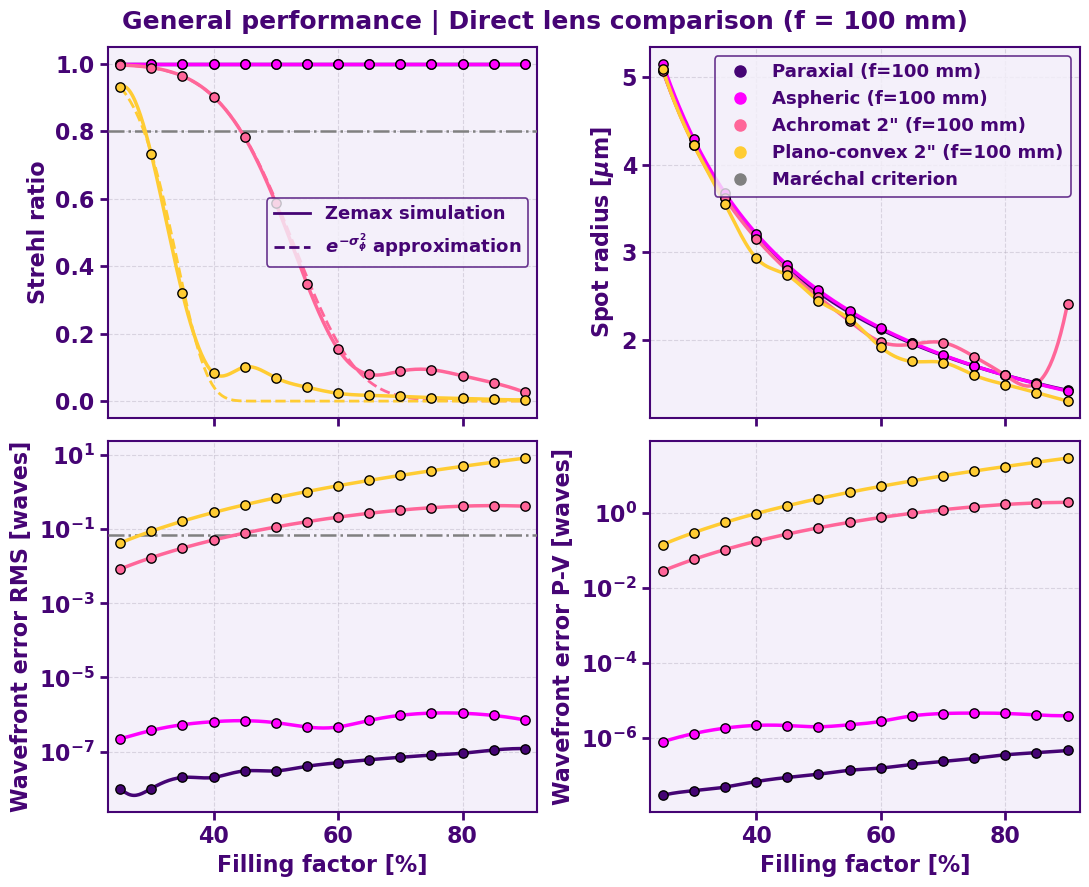

In [47]:
plot_general_performance(group1_dfs, group1_labels, 'Direct lens comparison (f = 100 mm)')

An evaluation of the rotationally symmetric Zernike terms reveals the structural mechanisms underlying the phase degradation observed across Group 1. The plano-convex singlet exhibits significant growth across all four evaluated aberration modes—defocus ($Z_4$), primary spherical ($Z_{11}$), secondary spherical ($Z_{22}$), and tertiary spherical ($Z_{37}$)—as higher aperture zones are illuminated. In contrast, the precision surface profile of the commercial aspheric lens virtually eliminates all orders, maintaining near-zero expansion across the full range of filling factors. Occupying an intermediate regime, the achromatic doublet provides robust correction for low-order terms, suppressing $Z_4$ and primary spherical aberration ($Z_{11}$) effectively up to moderate filling factors; however, its correction capability degrades for higher-order phase profiles, yielding secondary ($Z_{22}$) and tertiary ($Z_{37}$) spherical contributions comparable in magnitude to those of the simple singlet at high apertures.

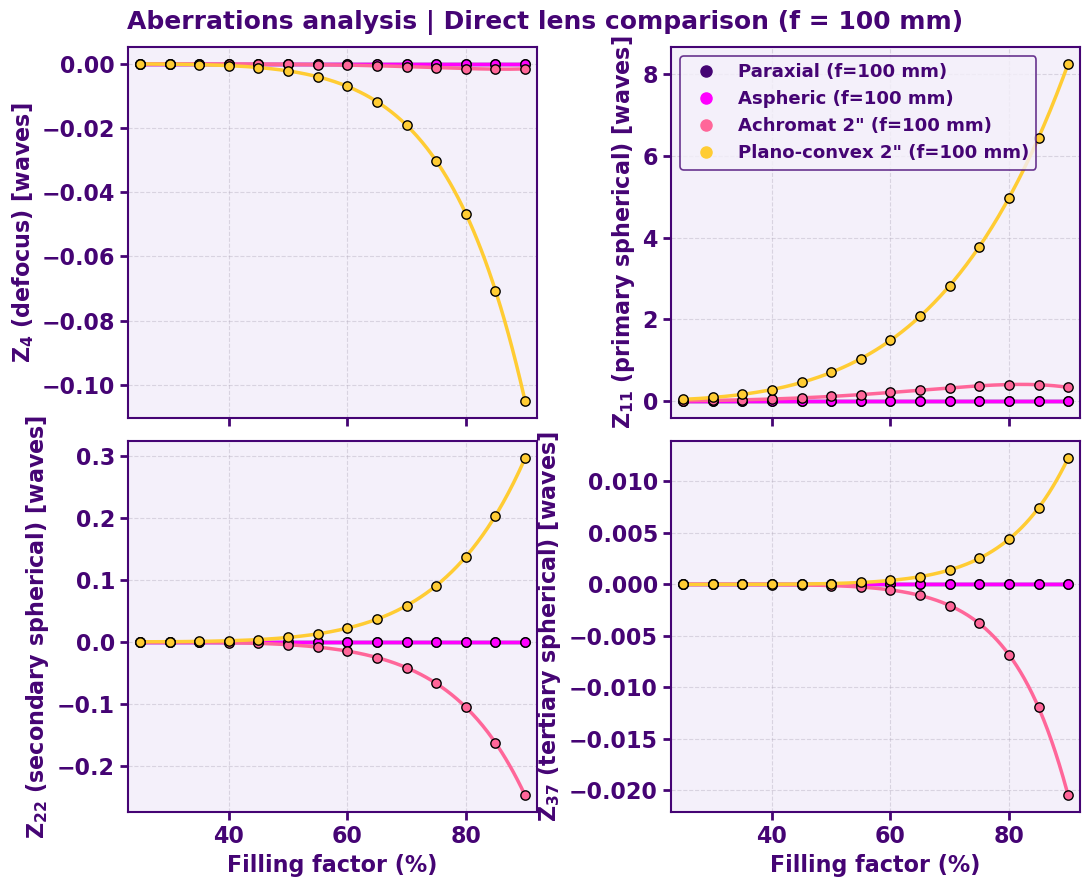

In [48]:
plot_aberration_analysis(group1_dfs, group1_labels, 'Direct lens comparison (f = 100 mm)')

# Inversion effect.

To provide a rigorous physical justification for the standard laboratory rule of thumb stating that collimated light must be incident on the curved surface of a lens, the subsequent three groups systematically investigate the inversion effect across distinct optical geometries. Reversing a lens alters the refraction angle distribution across its interfaces, significantly impacting the generation of marginal ray phase errors and total optical path difference. By evaluating the performance and Zernike aberration profiles of plano-convex singlets, achromatic doublets, and commercial diffraction-limited aspherics under both standard and inverted orientations, this study quantifies the precise limits of this empirical rule and demonstrates how geometry-dependent surface curvature minimizes high-order spherical aberration under truncated beam illumination.

## Achromat doublets.

The performance comparison for the achromatic doublet under inverted orientation confirms the validity of the traditional laboratory rule while revealing a subtle diffractive trade-off. Reversing the doublet introduces a severe refractive mismatch across its cemented interface and outer surface, causing a rapid breakdown in optical performance characterized by an accelerated drop in Strehl ratio and substantial wavefront error growth compared to the standard orientation. Interestingly, despite this severe phase degradation, the inverted configuration exhibits an apparent reduction in the central spot radius at higher filling factors, yielding a main intensity peak narrower than that of an ideal paraxial lens. This focal compression is not an enhancement in optical quality, but rather an artifact of extreme spherical aberration ($Z_{11}$), which severely redistributes energy from the central peak into bright outer diffraction rings, artificially narrowing the half-width of the remaining core. This structural change is fully explained by the Zernike polynomial evolution: inverting the doublet completely compromises its ability to correct low-order phase errors, causing $Z_4$ (defocus) and $Z_{11}$ (primary spherical aberration) to scale aggressively to magnitudes worse than those of a properly oriented plano-convex singlet, even though secondary ($Z_{22}$) and tertiary ($Z_{37}$) higher-order spherical terms remain marginally suppressed.

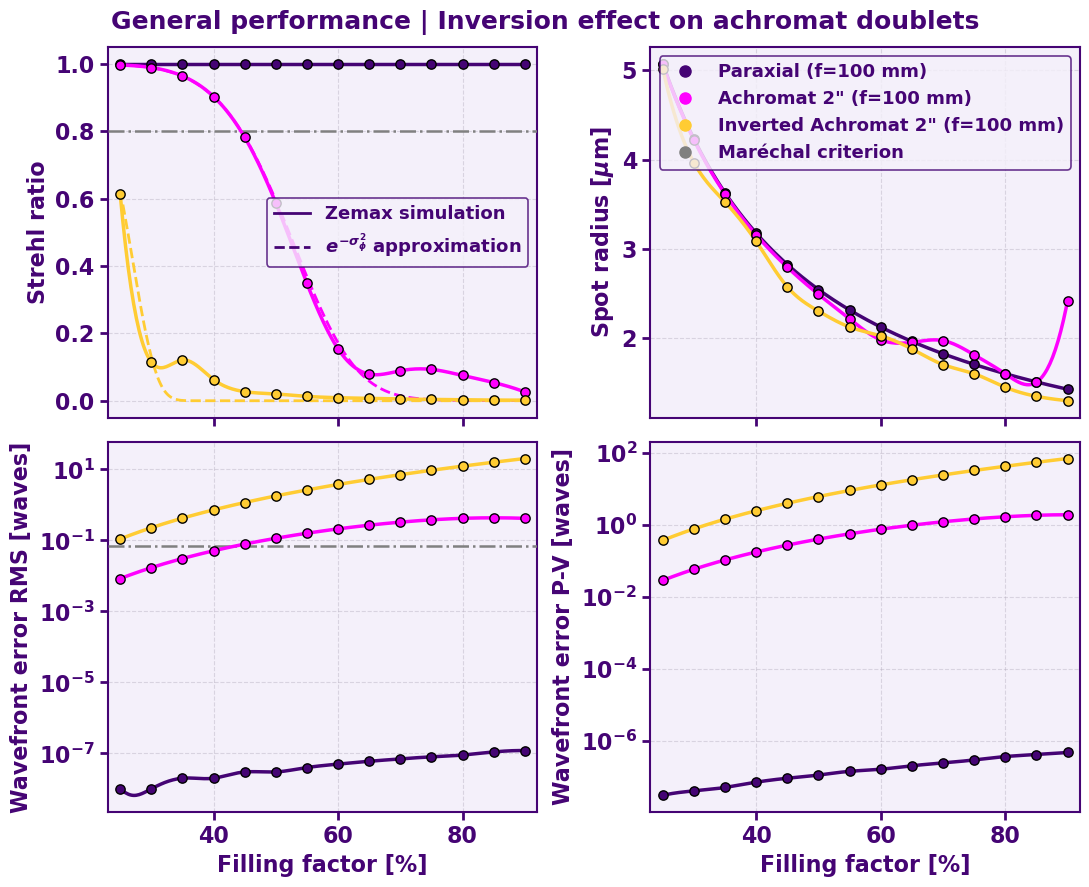

In [49]:
plot_general_performance(group2_dfs, group2_labels, 'Inversion effect on achromat doublets')

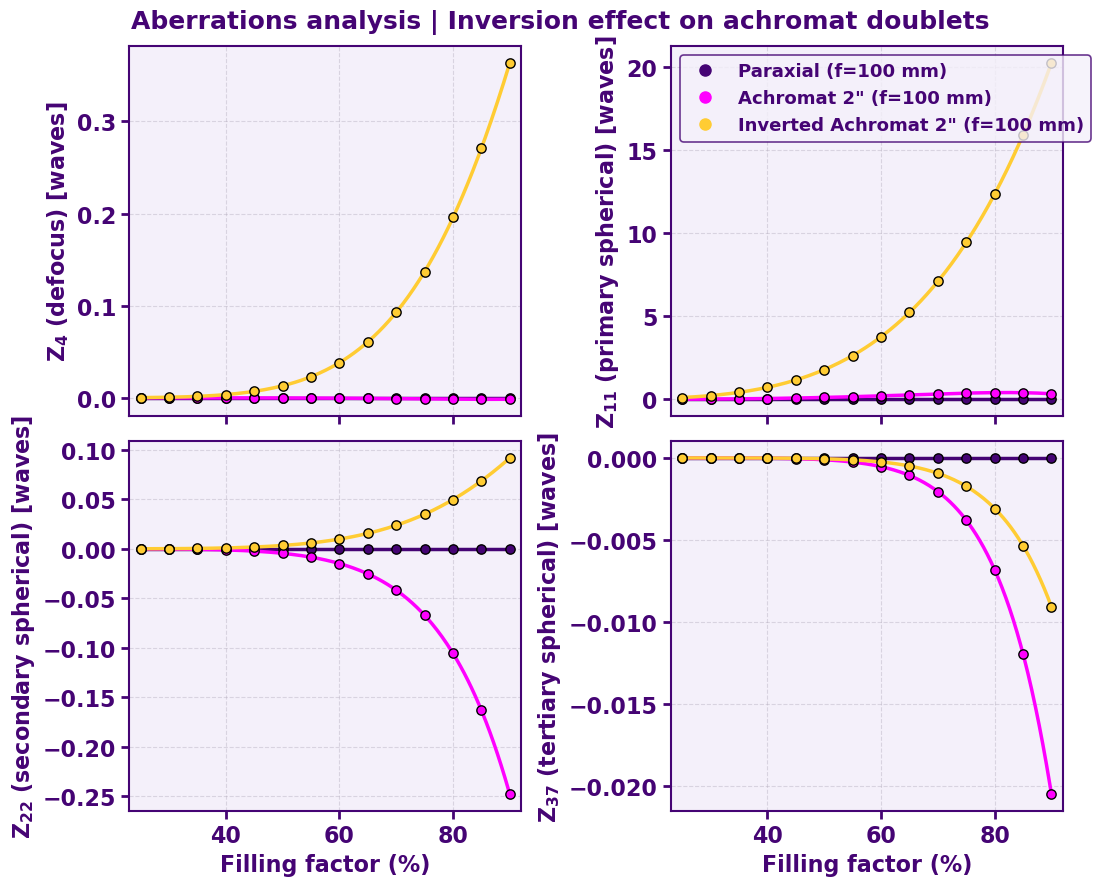

In [50]:
plot_aberration_analysis(group2_dfs, group2_labels, 'Inversion effect on achromat doublets')

## Aspheric lenses.

For the diffraction-limited aspheric lens, the inversion effect introduces the most dramatic performance drop among all tested configurations due to the precision-engineered nature of its surface profile. In its standard orientation, the custom surface shape perfectly cancels spherical aberration across the entire pupil, yielding performance metrics that nearly overlap with those of an ideal paraxial lens across all filling factors. Reversing the lens, however, forces collimated light to strike the planar surface first and refract through the aspheric contour at extreme, non-optimized angles. This structural mismatch causes a sudden collapse in Strehl ratio and immediate wavefront distortion, demonstrating that aspheric elements are exquisitely sensitive to alignment orientation and forfeit their diffraction-limited capability entirely when inverted.

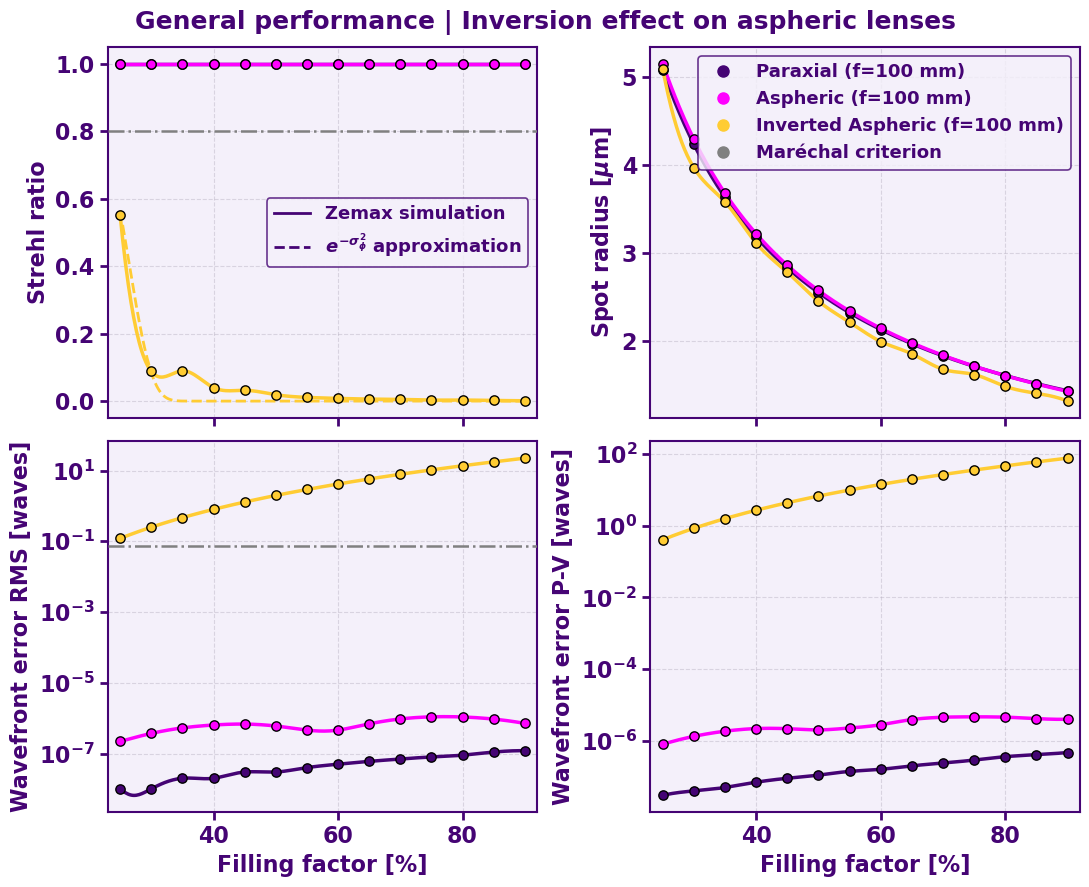

In [51]:
plot_general_performance(group3_dfs, group3_labels, 'Inversion effect on aspheric lenses')

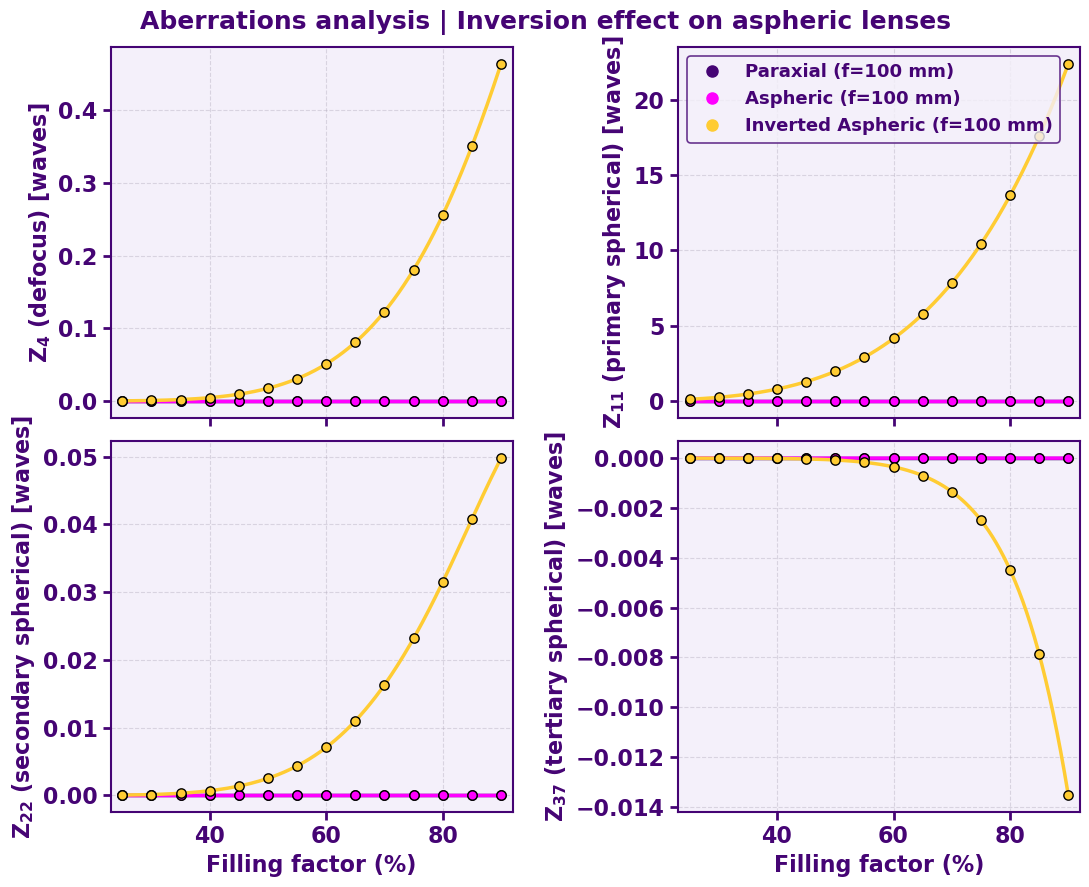

In [52]:
plot_aberration_analysis(group3_dfs, group3_labels, 'Inversion effect on aspheric lenses')

## Planoconvex singlets.

In the case of plano-convex singlets, reversing the orientation yields a performance degradation pattern consistent with the other geometries, though the relative change is less extreme at high pupil filling factors where marginal ray aberrations dominate in both configurations. While placing the curved surface toward collimated light remains the superior orientation—maintaining higher Strehl ratios and lower wavefront error—the performance curves begin to converge as the pupil fills completely, since severe refraction angles occur at high apertures regardless of orientation. Analysis of the Zernike polynomial expansion indicates that inverting the singlet causes a rapid increase in defocus ($Z_4$), primary spherical ($Z_{11}$), and secondary spherical ($Z_{22}$) terms. Intriguingly, tertiary spherical aberration ($Z_{37}$) remains largely invariant between the two orientations across the evaluated filling range, demonstrating that the structural penalty of reversing a simple singlet is primarily governed by lower- and mid-order spherical phase errors.

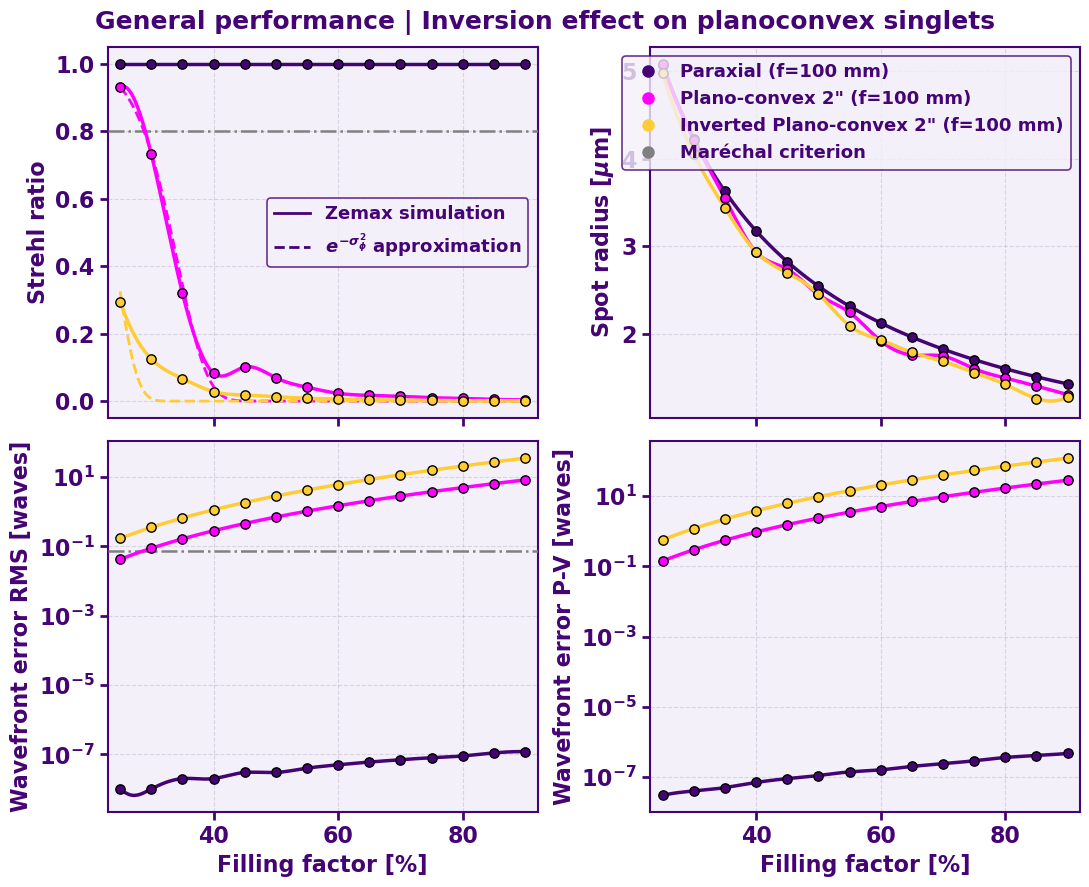

In [53]:
plot_general_performance(group4_dfs, group4_labels, 'Inversion effect on planoconvex singlets')

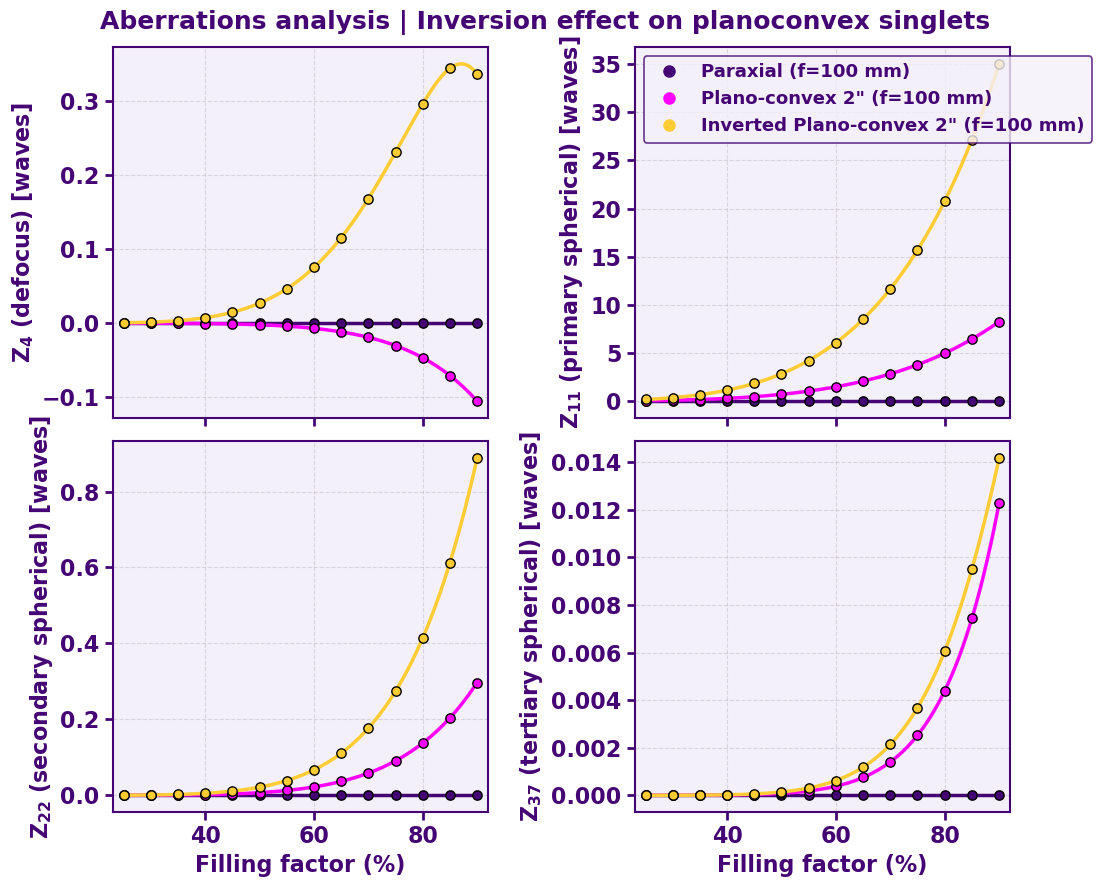

In [54]:
plot_aberration_analysis(group4_dfs, group4_labels, 'Inversion effect on planoconvex singlets')

# Focal length effect.

To evaluate the influence of focal length on optical performance under truncated illumination, the subsequent two groups analyze $2\text{"}$ diameter plano-convex singlets and achromatic doublets across focal lengths of $100\text{ mm}$, $150\text{ mm}$, and $200\text{ mm}$. From a geometric optics perspective, experimental physicists typically anticipate enhanced performance from longer focal length lenses, as an increased focal length yields a larger focal ratio ($f/\#$) for a fixed beam diameter. This higher $f/\#$ reduces the marginal refraction angles at the lens surfaces, thereby suppressing the magnitude of phase distortions. Comparing these configurations across varying pupil filling factors allows us to systematically verify this expectation, quantifying the extent to which longer focal lengths mitigate higher-order spherical aberrations and broaden the diffraction-limited operational regime.

## Achromat doublets.

The focal length comparison among $2\text{"}$ achromatic doublets clearly demonstrates the performance advantages of longer focal lengths, with the $200\text{ mm}$ variant maintaining diffraction-limited quality across the entire range of filling factors. By significantly suppressing all evaluated Zernike aberration terms, the $200\text{ mm}$ doublet approaches the aberration-free behavior of a commercial aspheric lens. However, this aberration correction involves a practical trade-off, as the focal spot radius scales directly with focal length according to $w_0 \propto f$, yielding a larger focused spot at $f=200\text{ mm}$ than at shorter focal lengths. This behavior suggests a cost-effective optical system architecture: utilizing long focal length doublets ($f \ge 200\text{ mm}$) within relay stages to transport beams without introducing significant phase distortions, followed by a single custom aspheric lens at the final focusing element to achieve a tightly focused spot on the sensor. Finally, while the Zernike aberration plots suggest a severe rise in phase errors for the $100\text{ mm}$ doublet, evaluating the vertical axis scale confirms that these absolute values remain relatively moderate and appear pronounced primarily because of the exceptional phase flatness achieved by the $150\text{ mm}$ and $200\text{ mm}$ doublets.

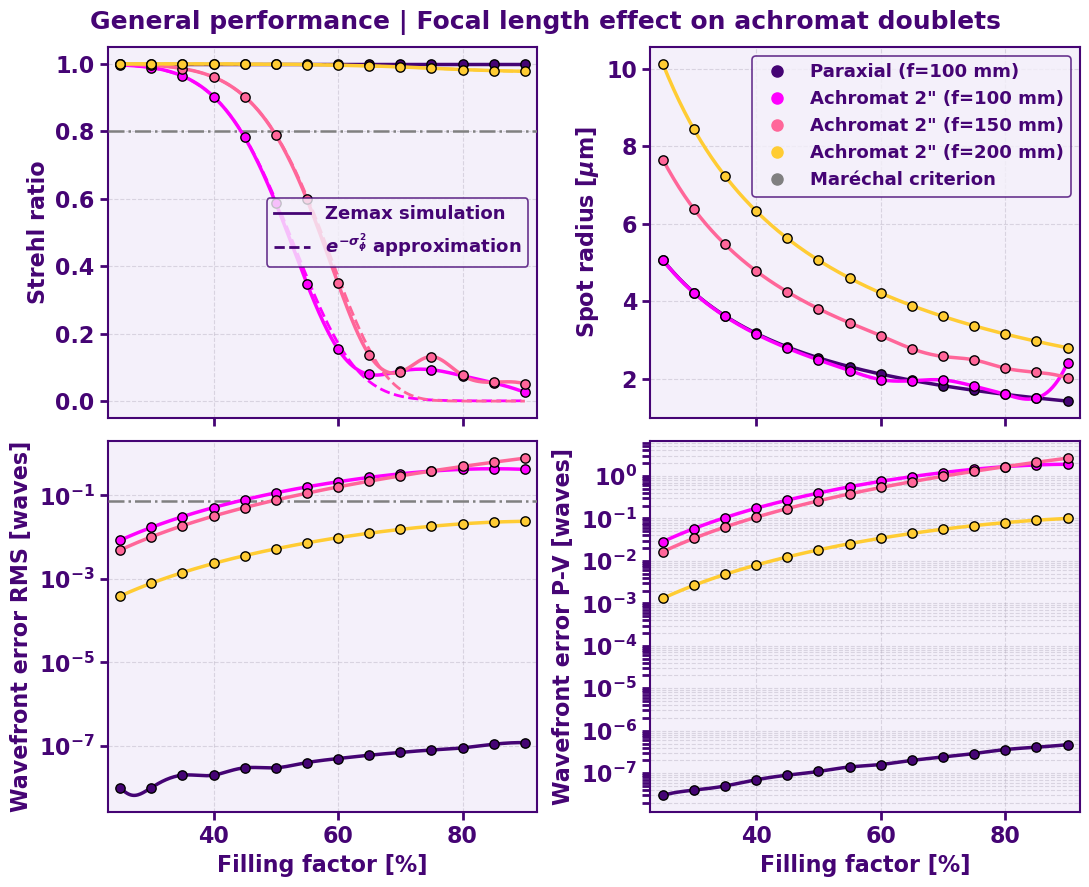

In [55]:
plot_general_performance(group5_dfs, group5_labels, 'Focal length effect on achromat doublets')

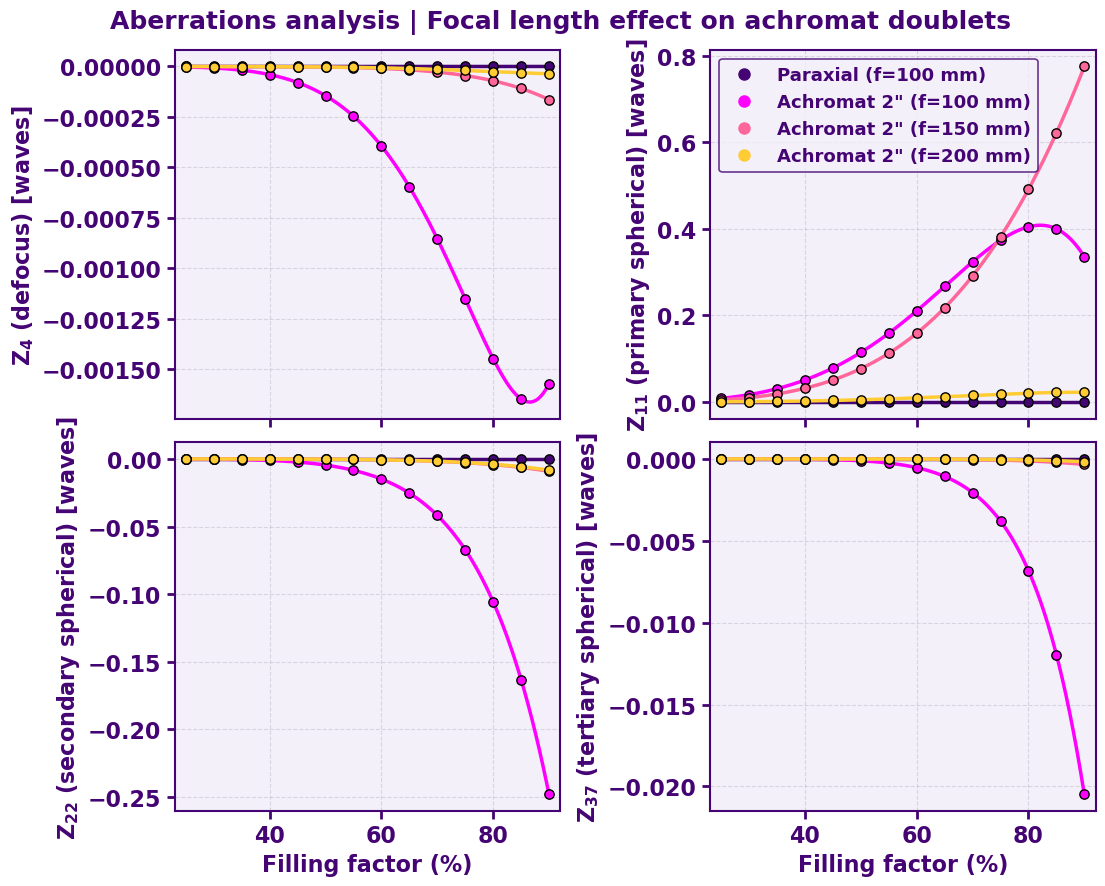

In [56]:
plot_aberration_analysis(group5_dfs, group5_labels, 'Focal length effect on achromat doublets')

## Planoconvex singlets.

A completely analogous behavior is observed for the $2\text{"}$ plano-convex singlets, confirming that increasing the focal length systematically suppresses phase errors across all pupil filling factors. In fact, a direct performance parallel can be drawn between the $200\text{ mm}$ singlet and the $100\text{ mm}$ doublet: both exhibit remarkably similar Strehl degradation profiles and Zernike aberration magnitudes, though the $100\text{ mm}$ doublet still maintains a clear advantage in primary spherical aberration correction. As with the doublet group, this reduction in phase distortion comes at the expense of spatial resolution at the focal plane; the intrinsic scaling $w_0 \propto f$ dictates that longer focal lengths produce larger diffraction spot radii, preserving the fundamental trade-off between minimizing wavefront aberrations and achieving high energy density at the focus.

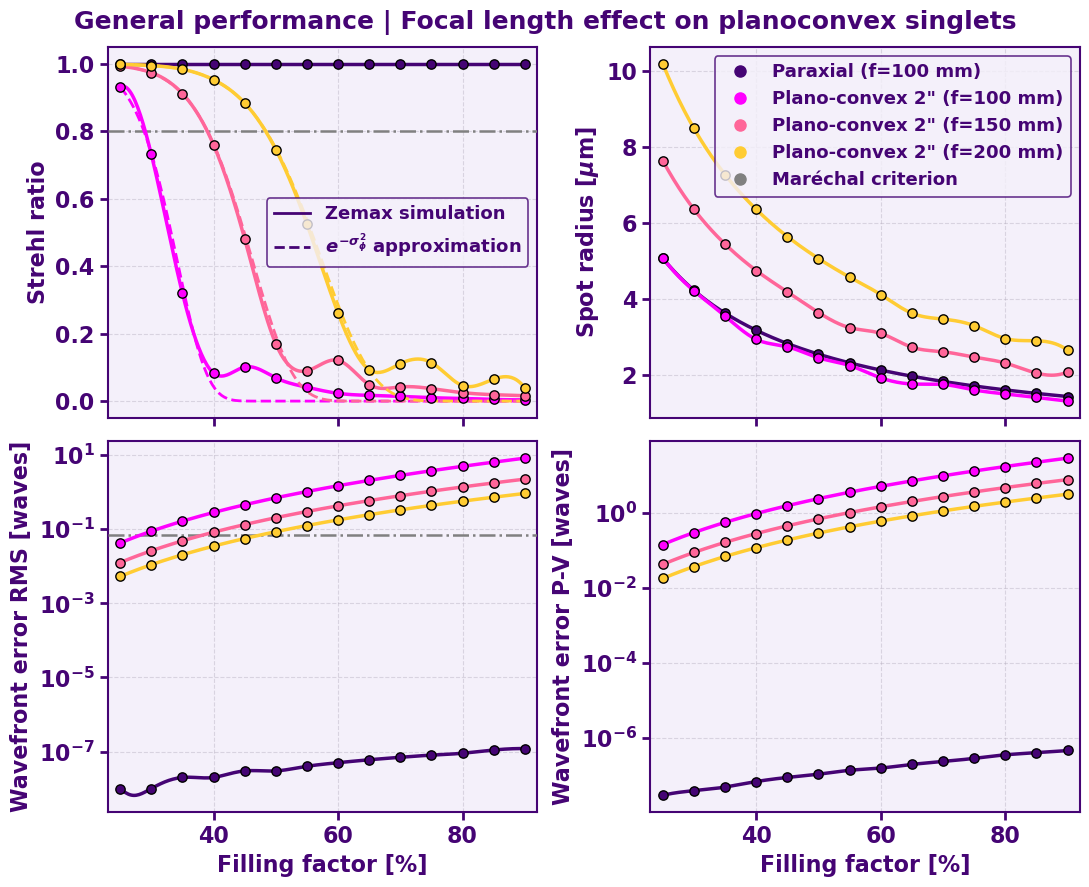

In [57]:
plot_general_performance(group6_dfs, group6_labels, 'Focal length effect on planoconvex singlets')

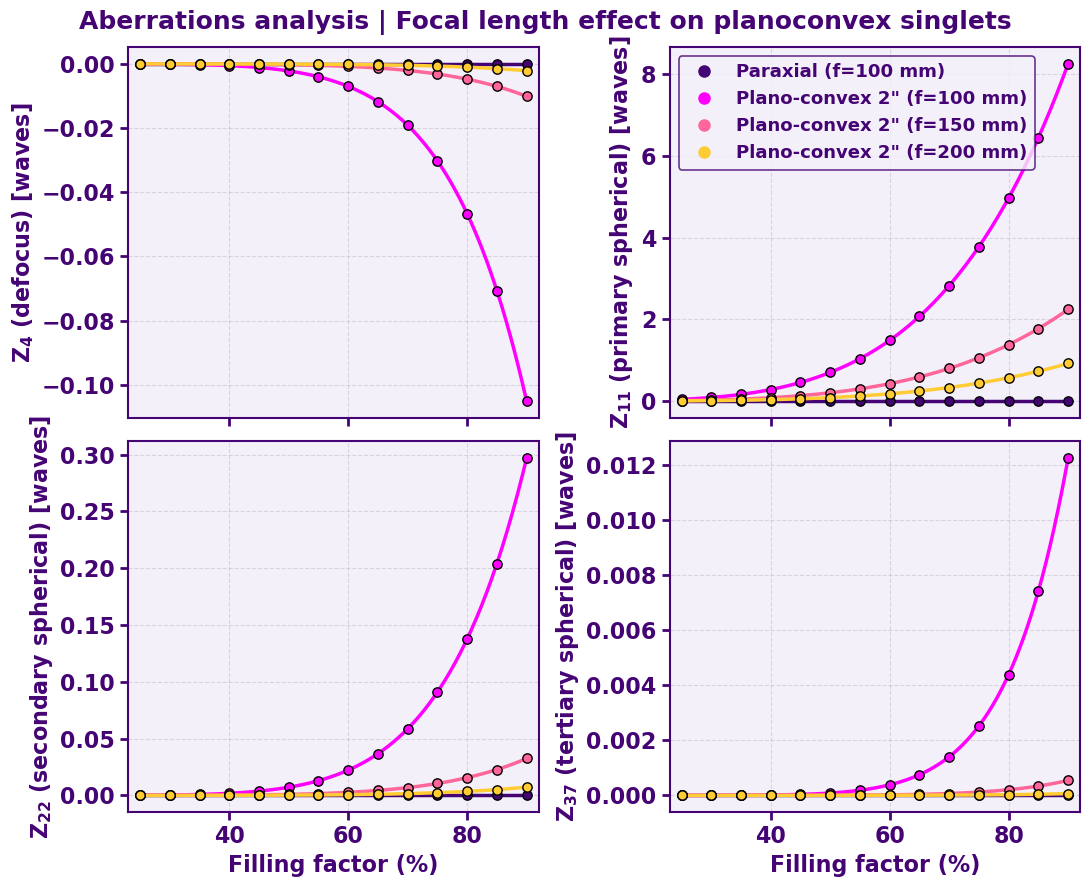

In [58]:
plot_aberration_analysis(group6_dfs, group6_labels, 'Focal length effect on planoconvex singlets')

# Diameter effect.

Comparing four achromatic doublets configured into two distinct $f/\#$ pairs—$1\text{"}$ ($f=50\text{ mm}$) with $2\text{"}$ ($f=100\text{ mm}$) for $f/2$, and $1\text{"}$ ($f=100\text{ mm}$) with $2\text{"}$ ($f=200\text{ mm}$) for $f/4$—demonstrates that optical performance groups primarily by the focal ratio rather than absolute clear aperture. Within each $f/\#$ family, lenses exhibit remarkably similar Strehl drops and Zernike aberration growth, though the smaller $1\text{"}$ diameter variants consistently yield slightly superior phase flatness due to reduced bulk glass path and edge thickness constraints. Nevertheless, the performance disparity between $f/2$ and $f/4$ systems remains far more dominant, confirming that operating at higher $f/\#$ values is the most effective strategy to suppress primary and higher-order spherical aberrations. These observations formulate a concise practical rule of thumb for laboratory design: utilize large-diameter, long-focal-length elements (high $f/\#$) to minimize wavefront degradation, while remaining mindful that longer focal lengths intrinsically broaden the focused diffraction spot ($w_0 \propto f$) and reduce final power density at the image plane.

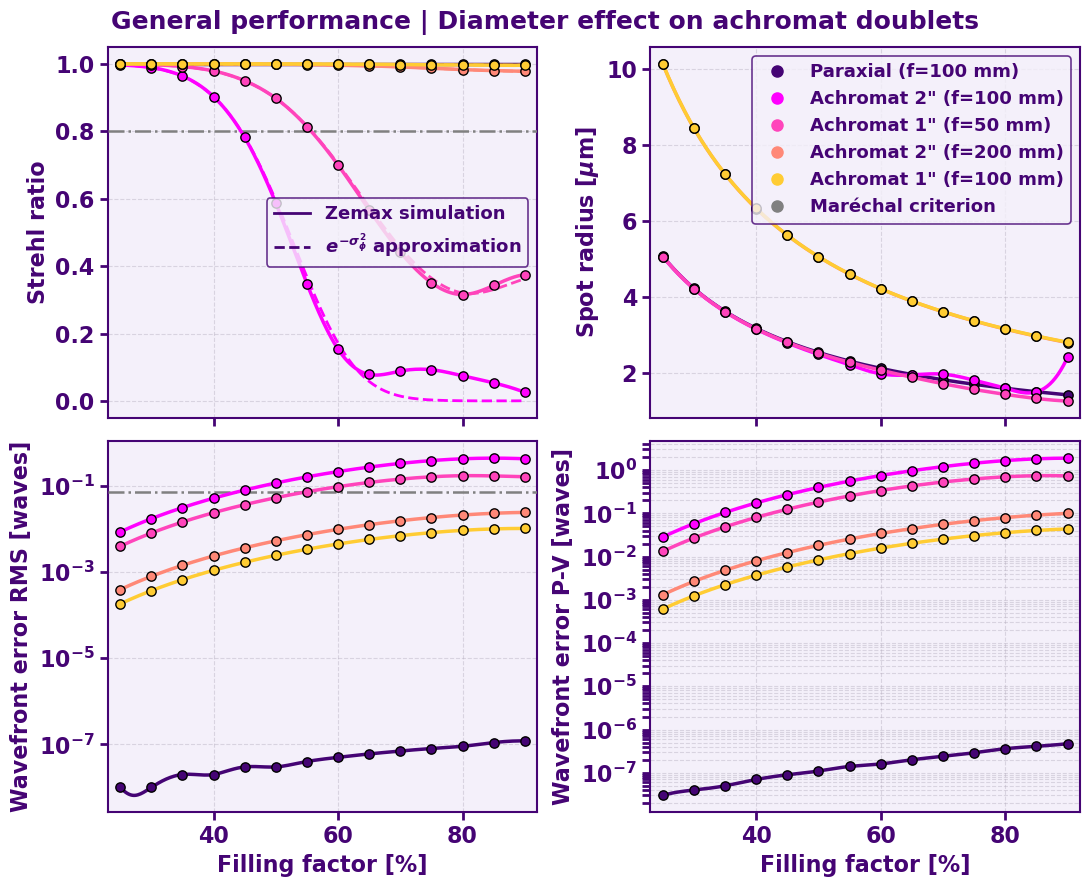

In [59]:
plot_general_performance(group7_dfs, group7_labels, 'Diameter effect on achromat doublets')

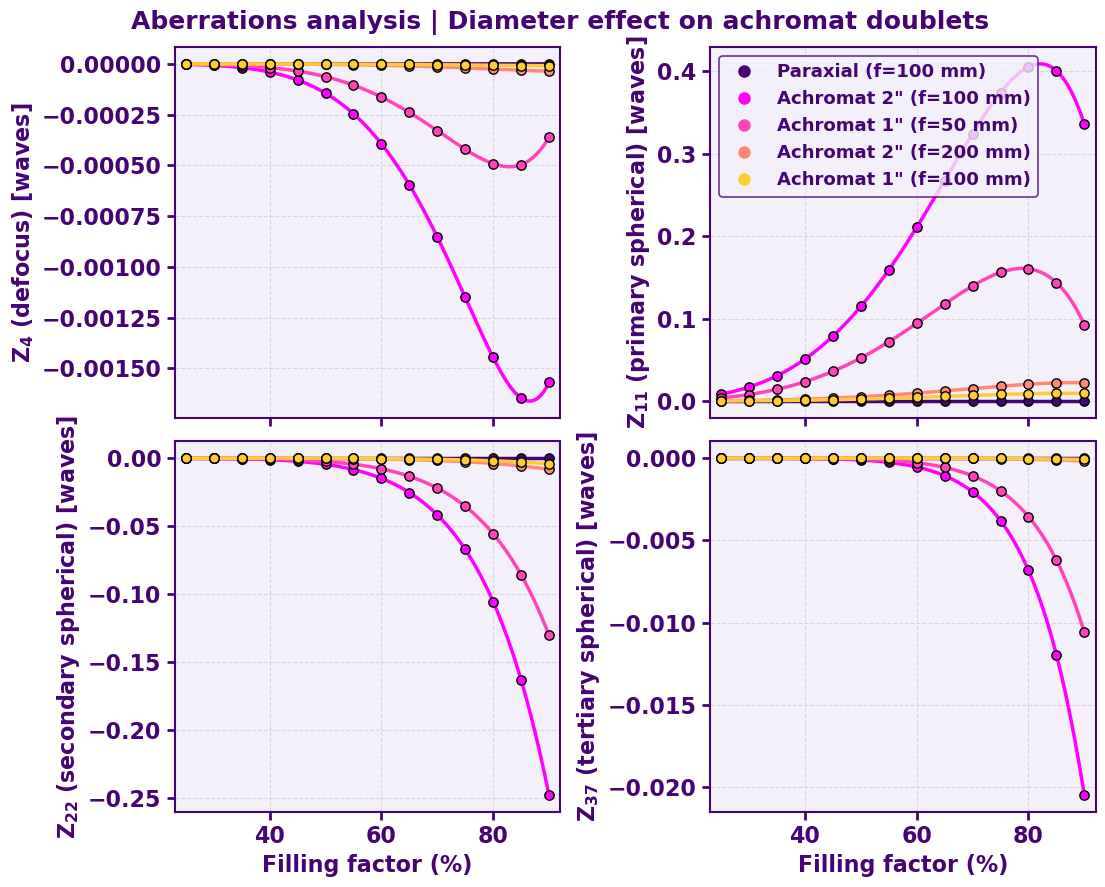

In [60]:
plot_aberration_analysis(group7_dfs, group7_labels, 'Diameter effect on achromat doublets')